# Explore data Analysis (EDA)
Exploratory Data Analysis (EDA) es el proceso de analizar conjuntos de datos para resumir sus características principales, a menudo utilizando métodos visuales. Es una etapa crucial en el análisis de datos, ya que permite a los analistas comprender mejor los datos, identificar patrones, detectar anomalías y formular hipótesis para análisis posteriores.


## **1. Cargar librerias y dataset**


In [202]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import MinMaxScaler

In [204]:
# Se cargan los datos
df = pd.read_csv('../data/raw/AB_NYC_2019.csv')
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [205]:
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


## **2. Analisis de los datos**

### **2.1 Analisis inicial de los datos**

In [274]:
df.shape


(48895, 16)

In [275]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [276]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

La mayoria de las columnas no tienen nulos, solo las columnas last_review y reviews_per_month tienen nulos, pero no es un gran problema, ya que se pueden rellenar con la media o la mediana de cada columna.

Tenemos varias columnas numéricas, como price, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count y availability_365. Estas columnas pueden ser analizadas para entender su distribución y su relación con otras variables.

Las columnas de tipo object, como name, host_name, neighbourhood_group, neighbourhood y room_type, pueden ser analizadas para entender su distribución y su relación con otras variables. Por ejemplo, se puede analizar la distribución de los tipos de habitación (room_type) y su relación con el precio (price).

Algnunas columnas como id y host_id son identificadores únicos, por lo que no aportan información relevante para el análisis y pueden ser descartadas en etapas posteriores del análisis.

La columna last_review es de tipo object, pero representa una fecha, por lo que se puede convertir a un formato de fecha para su análisis.

La columna name y host_name podrian contener información interesante sobre los anfitriones y las propiedades, por lo que se pueden analizar para entender su distribución y su relación con otras variables. Por ejemplo, se puede analizar la distribución de los nombres de los anfitriones (host_name) y su relación con el precio (price).

### **2.2 Entendiendo la estructura de los datos**

In [209]:
# Identificar el tipo de columnas y cuantas columnas numbericas tenemos
df.dtypes.value_counts()


int64      7
object     6
float64    3
Name: count, dtype: int64

In [210]:
# Conteo de tipos de variables
df.dtypes.describe()

count        16
unique        3
top       int64
freq          7
dtype: object

In [211]:
df.describe()


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Variable numericas: latitude, longitude, price, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count y availability_365

Variable categorica: name, host_name, neighbourhood_group, neighbourhood y room_type

Variable de fecha: last_review

Variables identificadores: id y host_id


### **2.3 Ver la calidad de los datos**

In [277]:
# Para las columnas de tipo object
df.isnull().sum()


id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [278]:
# Detectar los nulos para las columnas 
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [279]:
# Detectar las columnas con mayor porcentaje de nulos
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

last_review                       20.558339
reviews_per_month                 20.558339
host_name                          0.042949
name                               0.032723
id                                 0.000000
host_id                            0.000000
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

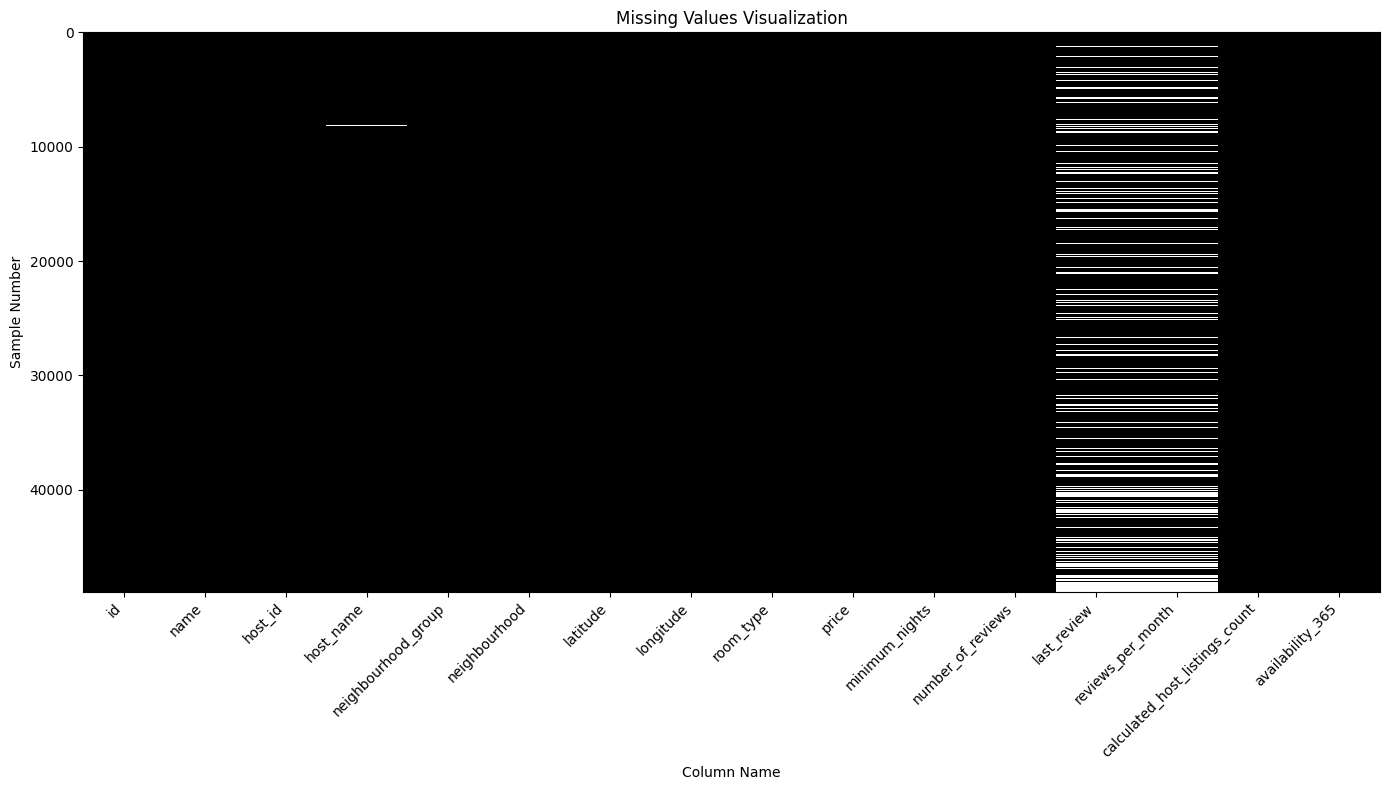

In [280]:
# Visualizar los datos nulos
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 8))
plt.imshow(df.isna(), aspect="auto", interpolation="nearest", cmap="gray")
plt.xticks(range(len(df.columns)), df.columns, rotation=45, ha='right')
plt.xlabel("Column Name")
plt.ylabel("Sample Number")
plt.title("Missing Values Visualization")
plt.tight_layout()
plt.show()

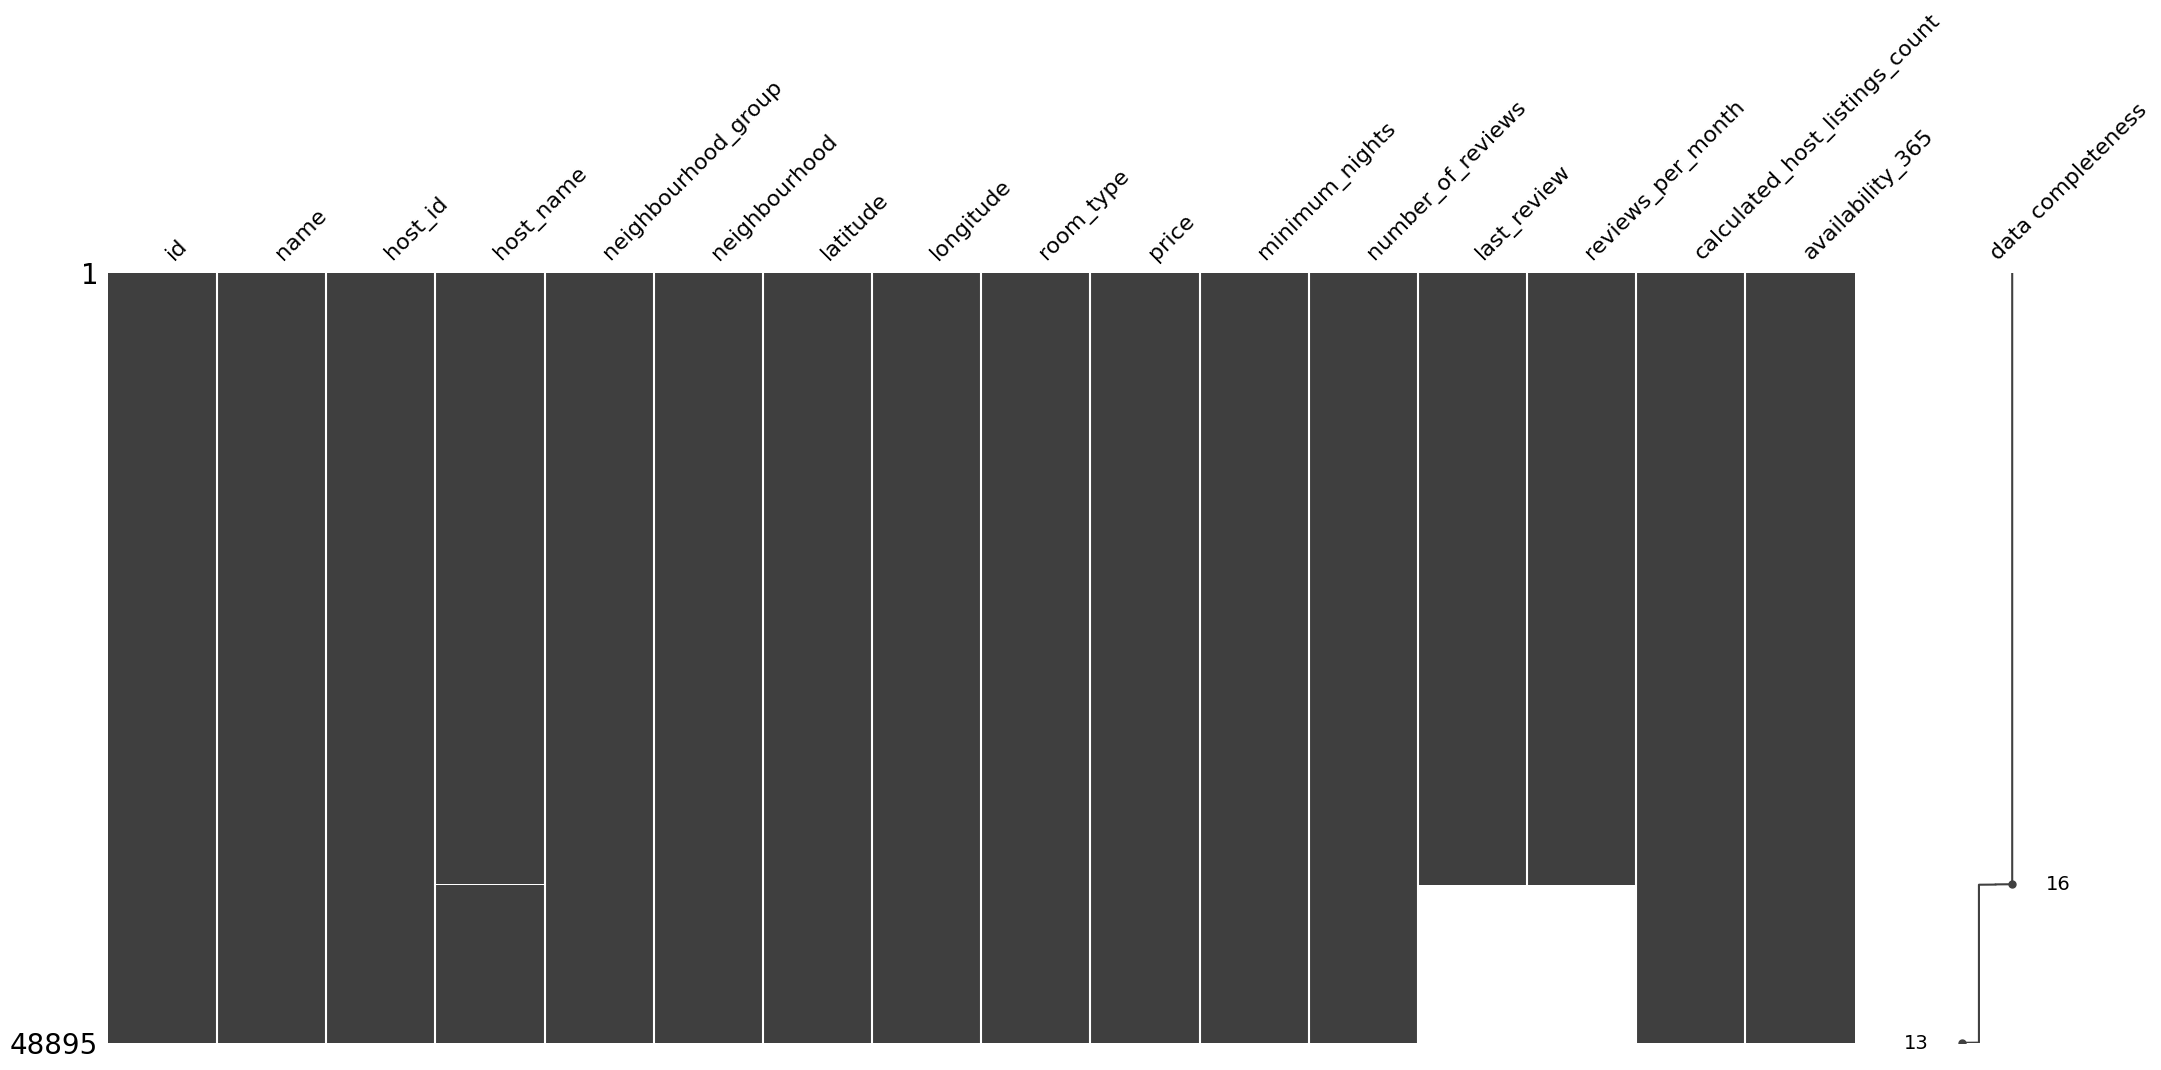

In [281]:
# Otra forma de visualizar los datos nulos

msno.matrix(df, labels=True, sort="descending");

In [282]:
df.select_dtypes(include=[np.number]).columns
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

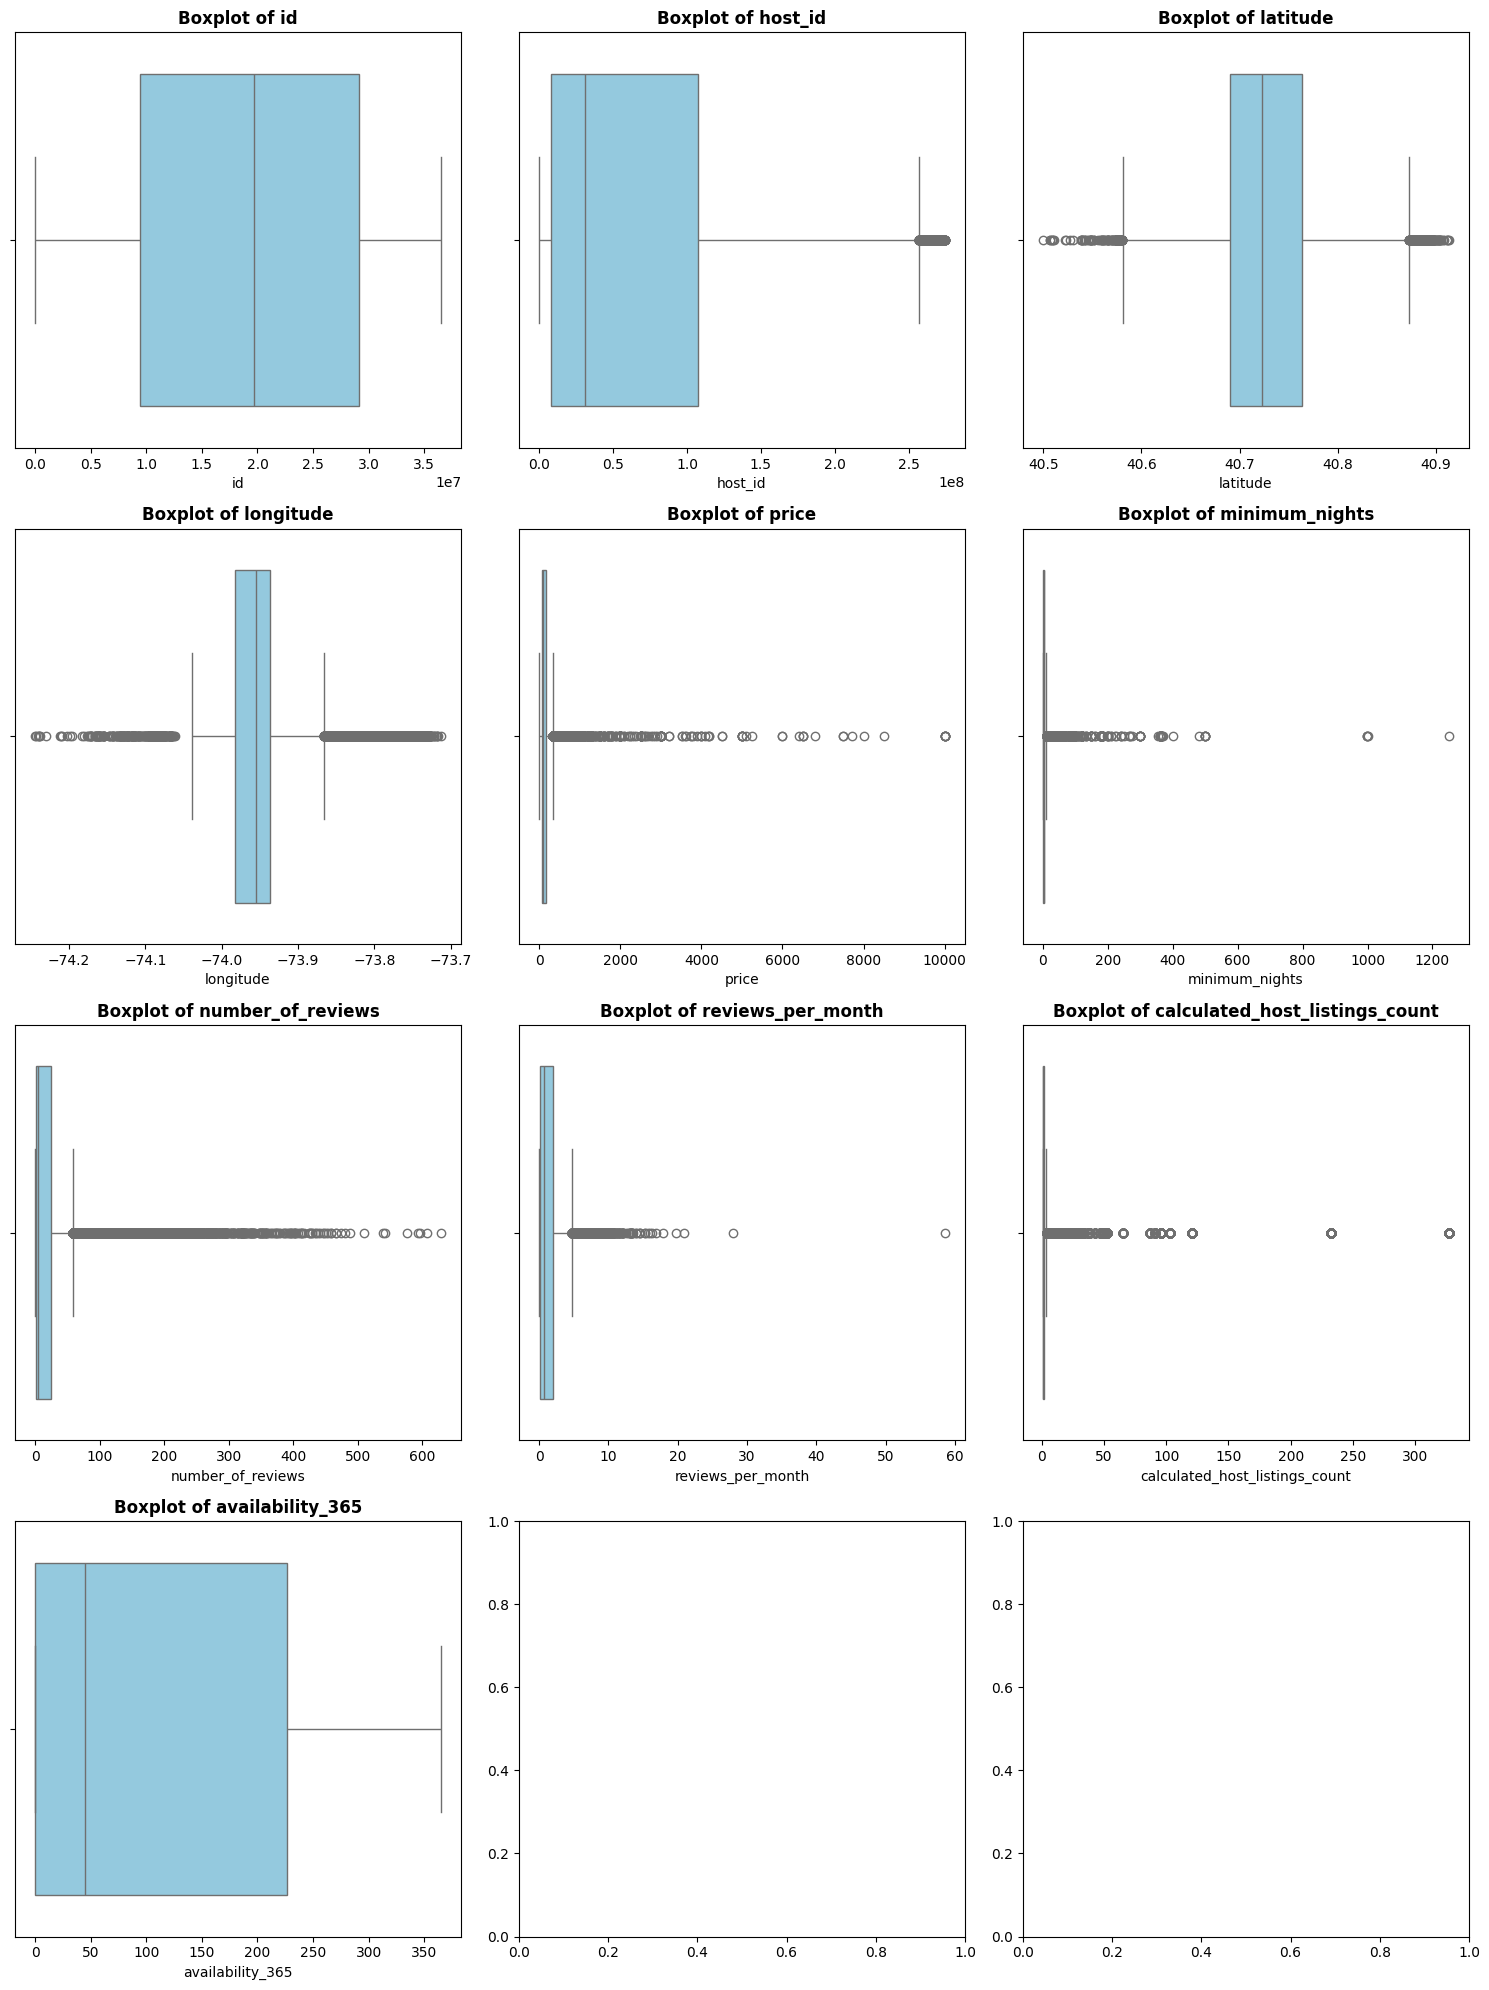

In [283]:
# Pasos para ver los outliers de cada variable numérica (3 gráficos por línea)
numeric_cols = df.select_dtypes(include=[np.number]).columns

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # Redondeo hacia arriba

# Crear figura con subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)

plt.tight_layout()
plt.show()

#### ** Interpretar datos - Analisis 1.**

* El dataframe tiene un total de 48895 filas que representan la información de Airbnb en Nueva York. 

* Columnas numericas: latitude, longitude, price, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count y availability_365

* Columnas categorica: name, host_name, neighbourhood_group, neighbourhood y room_type

* Columnas con fecha: last_review

* Columnas con identificadores: id y host_id

* Las columnas  **last_review** y **review_per_month** tienen 20.5% valores nulos.



### **2.4 Analicemos las variables categoricas**


In [219]:
#REVISEMOS LOS POSIBLES DATOS CATEGÓRICOS
df.select_dtypes(include=['object']).columns


Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='object')

In [220]:
df['name']

0                       Clean & quiet apt home by the park
1                                    Skylit Midtown Castle
2                      THE VILLAGE OF HARLEM....NEW YORK !
3                          Cozy Entire Floor of Brownstone
4         Entire Apt: Spacious Studio/Loft by central park
                               ...                        
48890      Charming one bedroom - newly renovated rowhouse
48891        Affordable room in Bushwick/East Williamsburg
48892              Sunny Studio at Historical Neighborhood
48893                 43rd St. Time Square-cozy single bed
48894    Trendy duplex in the very heart of Hell's Kitchen
Name: name, Length: 48895, dtype: object

In [221]:
df['host_name'].unique
df.groupby('host_name').size().sort_values(ascending=False)

host_name
Michael         417
David           403
Sonder (NYC)    327
John            294
Alex            279
               ... 
Jerbean           1
Jerald            1
Jeonghoon         1
Jeny              1
현선                1
Length: 11452, dtype: int64

In [222]:
# Group by neighbourhood and count records
df.groupby('neighbourhood').size().sort_values(ascending=False)



neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Willowbrook              1
Fort Wadsworth           1
New Dorp                 1
Woodrow                  1
Length: 221, dtype: int64

In [223]:
# Group by neighbourhood_group and count records
df.groupby('neighbourhood_group').size().sort_values(ascending=False)


neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
dtype: int64

In [224]:
# Group by room_type and count records
df.groupby('room_type').size().sort_values(ascending=False)


room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
dtype: int64

In [225]:
# Group by last_review and count records
df.groupby('last_review').size().sort_values(ascending=False)

last_review
2019-06-23    1413
2019-07-01    1359
2019-06-30    1341
2019-06-24     875
2019-07-07     718
              ... 
2015-01-07       1
2014-12-30       1
2014-12-22       1
2014-12-19       1
2011-03-28       1
Length: 1764, dtype: int64

In [226]:
# Group by neighbourhood and count records
df.groupby('neighbourhood').size().sort_values(ascending=False)

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Willowbrook              1
Fort Wadsworth           1
New Dorp                 1
Woodrow                  1
Length: 221, dtype: int64

#### ** Interpretar datos - Analisis 2.**

* El dataframe tiene un total de 48895 filas que representan la información de Airbnb en Nueva York. 

* Columnas numericas: latitude, longitude, price, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count y availability_365

* Columnas categorica: name, host_name, neighbourhood_group, neighbourhood y room_type

* Columnas con fecha: last_review

* Columnas con identificadores: id y host_id

* Las columnas  **last_review** y **review_per_month** tienen 20.5% valores nulos.

* En principio descarto las columnas id y host_id, ya que son identificadores únicos y no aportan información relevante para el análisis.

* Descarto las columnas name y host_name, ya que no aportan información relevante para el análisis, aunque podrían contener información interesante sobre los anfitriones y las propiedades, por lo que se pueden analizar para entender su distribución y su relación con otras variables. Por ejemplo, se puede analizar la distribución de los nombres de los anfitriones (host_name) y su relación con el precio (price).

* Factorizo las columnas neighbourhood_group, neirhbourhood y room type

* Las columnas de tipo last_review y review per month, pueden ser utiles para analizar con otras variables, para ver price. 

* Como en este caso no tenemos definido un objectivo, he decidido definir **"price"** como el objetivo a estimar 


### **2.5 Eliminar duplicados**

In [227]:
# Mirar el numero de duplicados 
total_duplicate_rows = df.duplicated().sum()
print(f"Numero de duplicados en el dataframe: {total_duplicate_rows}")

# Repetidos en cada columna
print("\n" + "="*70)
print("Repetidos en cada columna:")
print("="*70)

has_duplicates = False
for column in df.columns:
    # Contar cuántos valores aparecen más de una vez
    duplicated_values = df[column].duplicated().sum()
    
    if duplicated_values > 0:
        has_duplicates = True
        # Total de registros con valores duplicados (incluyendo todas las ocurrencias)
        total_duplicated = df[column].value_counts()[df[column].value_counts() > 1].sum()
        # Número de valores únicos que están duplicados
        unique_duplicated = df[column].value_counts()[df[column].value_counts() > 1].count()
        
        print(f"\n📌 {column}:")
        print(f"   • Entradas duplicadas (excluyendo la primera): {duplicated_values:,}")
        print(f"   • Total de registros con valores duplicados: {total_duplicated:,}")
        print(f"   • Valores únicos que aparecen >1 vez: {unique_duplicated:,}")

if not has_duplicates:
    print("\n✅ No se encontraron valores duplicados en ninguna columna")

Numero de duplicados en el dataframe: 0

Repetidos en cada columna:

📌 name:
   • Entradas duplicadas (excluyendo la primera): 989
   • Total de registros con valores duplicados: 1,619
   • Valores únicos que aparecen >1 vez: 645

📌 host_id:
   • Entradas duplicadas (excluyendo la primera): 11,438
   • Total de registros con valores duplicados: 16,592
   • Valores únicos que aparecen >1 vez: 5,154

📌 host_name:
   • Entradas duplicadas (excluyendo la primera): 37,442
   • Total de registros con valores duplicados: 41,971
   • Valores únicos que aparecen >1 vez: 4,549

📌 neighbourhood_group:
   • Entradas duplicadas (excluyendo la primera): 48,890
   • Total de registros con valores duplicados: 48,895
   • Valores únicos que aparecen >1 vez: 5

📌 neighbourhood:
   • Entradas duplicadas (excluyendo la primera): 48,674
   • Total de registros con valores duplicados: 48,889
   • Valores únicos que aparecen >1 vez: 215

📌 latitude:
   • Entradas duplicadas (excluyendo la primera): 29,847
  

No hay enteros duplicados en el dataframe, por lo que no es necesario eliminar ningún registro.

### **2.6 Eliminar informacion irrelevante**

Considero que las columnas id y host_id son identificadores únicos, por lo que no aportan información relevante para el análisis y pueden ser descartadas en etapas posteriores del análisis.
Considero que las columnas name y host_name no aportan información relevante para el análisis, aunque podrían contener información interesante sobre los anfitriones y las propiedades, por lo que se pueden analizar para entender su distribución y su relación con otras variables, pero estan fuera del objeto de este estudio.
Considero que las columnas de tipo last_review y review per month, pueden ser utiles para analizar con otras variables, para ver price. Como en este caso no tenemos definido un objectivo las voy a descartar.


In [228]:
# Guardar copia del dataframe original

df_initial = df.copy()

# Eliminar columnas irrelevantes
df_clean = df.drop(columns=['id', 'host_id', 'name', 'host_name', 'last_review', 'reviews_per_month'])

# Verificar las columnas eliminadas
print(f"Columnas originales: {df_initial.shape[1]}")
print(f"Columnas después de limpieza: {df_clean.shape[1]}")
print(f"\nColumnas eliminadas: {df_initial.shape[1] - df_clean.shape[1]}")
print(f"\nColumnas restantes en df_clean:")
print(df_clean.columns.tolist())



Columnas originales: 16
Columnas después de limpieza: 10

Columnas eliminadas: 6

Columnas restantes en df_clean:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365']


In [229]:
df_clean.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [230]:
# Visualizar el dataframe limpio
df_clean.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


### **2.7 Factorizar las variables categóricas**

Las variables categóricas que vamos a factorizar son:
- **`room_type`**: Tipo de habitación (Entire home/apt, Private room, Shared room)
- **`neighbourhood_group`**: Borough de NYC (Manhattan, Brooklyn, Queens, Bronx, Staten Island)


#### Factorizo room_type

In [231]:
set(list(df_clean["room_type"]))

{'Entire home/apt', 'Private room', 'Shared room'}

In [232]:
# Factorizamos con pd.factorize, donde el primer elemento es 0 y asi sucesivamente
df_clean["room_type_factor"] = pd.factorize(df_clean["room_type"])[0]
df_clean[['room_type','room_type_factor']]

,room_type,room_type_factor
0,Private room,0
1,Entire home/apt,1
2,Private room,0
3,Entire home/apt,1
4,Entire home/apt,1
...,...,...
48890,Private room,0
48891,Private room,0
48892,Entire home/apt,1
48893,Shared room,2


In [233]:
# Check the values of the new factorized column
df_clean["room_type_factor"].unique()

array([0, 1, 2])

In [234]:
# Crear un diccionario para guardar las reglas de transformación
room_type_transformation_rules = (
    df_clean[['room_type', 'room_type_factor']]
    .drop_duplicates()
    .set_index('room_type')['room_type_factor']
    .to_dict()
)

room_type_transformation_rules

{'Private room': 0, 'Entire home/apt': 1, 'Shared room': 2}

In [235]:
# Se almacenan las reglas de transformación en un archivo JSON
import json
with open('sex_transformation_rules.json', 'w') as f:
    json.dump(room_type_transformation_rules,f)

#### Factorizo neighbourhood_group

In [236]:
set(list(df_clean['neighbourhood_group']))

{'Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'}

In [237]:
# Factorizamos con pd.factorize, donde el primer elemento es 0 y asi sucesivamente
df_clean["neighbourhood_group_factor"] = pd.factorize(df_clean["neighbourhood_group"])[0]
df_clean[['neighbourhood_group','neighbourhood_group_factor']]

,neighbourhood_group,neighbourhood_group_factor
0,Brooklyn,0
1,Manhattan,1
2,Manhattan,1
3,Brooklyn,0
4,Manhattan,1
...,...,...
48890,Brooklyn,0
48891,Brooklyn,0
48892,Manhattan,1
48893,Manhattan,1


In [238]:
# Check the values of the new factorized column
df_clean["neighbourhood_group_factor"].unique()

array([0, 1, 2, 3, 4])

In [239]:
# Crear un diccionario para guardar las reglas de transformación
neighbourhood_group_transformation_rules = (
    df_clean[['neighbourhood_group', 'neighbourhood_group_factor']]
    .drop_duplicates()
    .set_index('neighbourhood_group')['neighbourhood_group_factor']
    .to_dict()
)
neighbourhood_group_transformation_rules


{'Brooklyn': 0, 'Manhattan': 1, 'Queens': 2, 'Staten Island': 3, 'Bronx': 4}

In [240]:
# Se almacenan las reglas de transformación en un archivo JSON
import json
with open('neighbourhood_group_transformation_rules.json', 'w') as f:
    json.dump(neighbourhood_group_transformation_rules,f)

### **4. Análisis Variables Univariante**

* Cuando hablamos de una variable **univariante** nos referimos a un termino **estadístico** que se emplea para referenciar un conjunto de observaciones de un atributo.

* En palabras sencillas, analizamos **columna a columna** del DataFrame.

* Por ello, debemos distinguir si la variable es una **variable categórica o numérica**, ya que el cuerpo del análisis y las conclusiones que se pueden obtener serán distintas.

* **VARIABLE CATEGÓRICA:** es un tipo de variable que puede tomar un número limitado de categorías o grupos.
    * Grupos Nominales: por ejemplo el color de un coche puede ser rojo, azul, negro, etc... pero ninguno de estos colores es inminentemente "mayor" o "mejor" que los demás.

Las variables categóricas para este dataset son:
neighbourhood_group
neighbourhood
room_type


#### Analisis en las variables categoricas

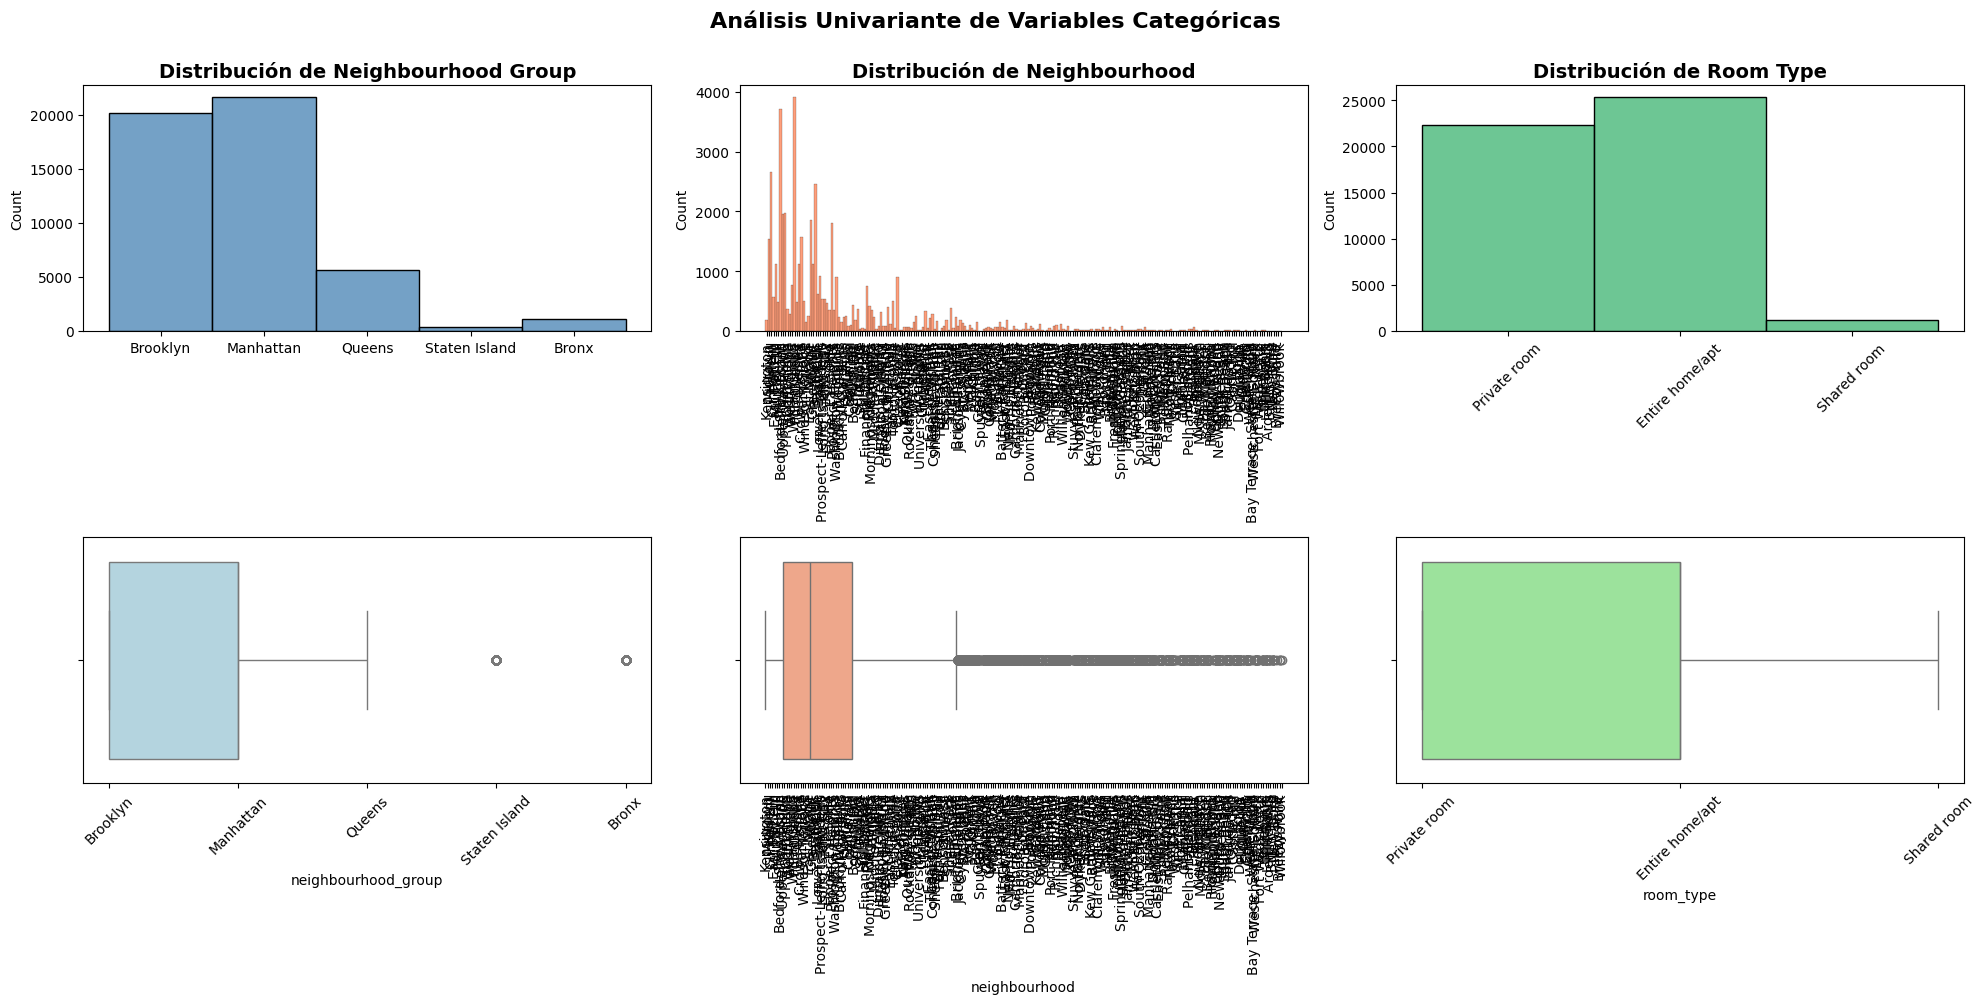

In [241]:
# Análisis univariante de las 3 variables categóricas
fig, axis = plt.subplots(2, 3, figsize=(20, 10))

# Neighbourhood Group
sns.histplot(ax=axis[0, 0], data=df_clean, x="neighbourhood_group", color='steelblue').set(xlabel=None)
axis[0, 0].set_title('Distribución de Neighbourhood Group', fontsize=14, fontweight='bold')
sns.boxplot(ax=axis[1, 0], data=df_clean, x="neighbourhood_group", color='lightblue')
axis[1, 0].tick_params(axis='x', rotation=45)

# Neighbourhood
sns.histplot(ax=axis[0, 1], data=df_clean, x="neighbourhood", color='coral').set(xlabel=None)
axis[0, 1].set_title('Distribución de Neighbourhood', fontsize=14, fontweight='bold')
axis[0, 1].tick_params(axis='x', rotation=90)
sns.boxplot(ax=axis[1, 1], data=df_clean, x="neighbourhood", color='lightsalmon')
axis[1, 1].tick_params(axis='x', rotation=90)

# Room Type
sns.histplot(ax=axis[0, 2], data=df_clean, x="room_type", color='mediumseagreen').set(xlabel=None)
axis[0, 2].set_title('Distribución de Room Type', fontsize=14, fontweight='bold')
axis[0, 2].tick_params(axis='x', rotation=45)
sns.boxplot(ax=axis[1, 2], data=df_clean, x="room_type", color='lightgreen')
axis[1, 2].tick_params(axis='x', rotation=45)

plt.suptitle('Análisis Univariante de Variables Categóricas', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [242]:
# Analizar neighbourhood
top_neighbourhoods = df_clean['neighbourhood'].value_counts().head(10)


top_neighbourhoods_with_percentage = df_clean['neighbourhood'].value_counts(normalize=True).head(10) * 100
for neighbourhood, percentage in top_neighbourhoods_with_percentage.items():
    count = df_clean[df_clean['neighbourhood'] == neighbourhood].shape[0]
    print(f"{neighbourhood:30} {count:6} listados ({percentage:5.2f}%)")

print(f"\n🏆 El barrio con MÁS listados es: '{df_clean['neighbourhood'].value_counts().index[0]}' con {df_clean['neighbourhood'].value_counts().iloc[0]} registros")


Williamsburg                     3920 listados ( 8.02%)
Bedford-Stuyvesant               3714 listados ( 7.60%)
Harlem                           2658 listados ( 5.44%)
Bushwick                         2465 listados ( 5.04%)
Upper West Side                  1971 listados ( 4.03%)
Hell's Kitchen                   1958 listados ( 4.00%)
East Village                     1853 listados ( 3.79%)
Upper East Side                  1798 listados ( 3.68%)
Crown Heights                    1564 listados ( 3.20%)
Midtown                          1545 listados ( 3.16%)

🏆 El barrio con MÁS listados es: 'Williamsburg' con 3920 registros


In [243]:
# Analizar room_type
top_rooms= df_clean['room_type'].value_counts().head(10)
top_room_with_percentage = df_clean['room_type'].value_counts(normalize=True).head(10) * 100
for room_type, percentage in top_room_with_percentage.items():
    count = df_clean[df_clean['room_type'] == room_type].shape[0]
    print(f"{room_type:30} {count:6} listados ({percentage:5.2f}%)")


Entire home/apt                 25409 listados (51.97%)
Private room                    22326 listados (45.66%)
Shared room                      1160 listados ( 2.37%)


1. Neighbourhood_group
- Hay 5 valores, la mayoria de los valores estan en Broooklyn y Manhattan

2. Neightbout_hood
- Hay muchisimos valores, los barrios con mas ocurrencias Williamsburg and Bedford.

3. Room_type
- La mayoria tiene Entire home o Private room, un porcentaje muy pequeño es shared room

#### Analisis en las variables numericas

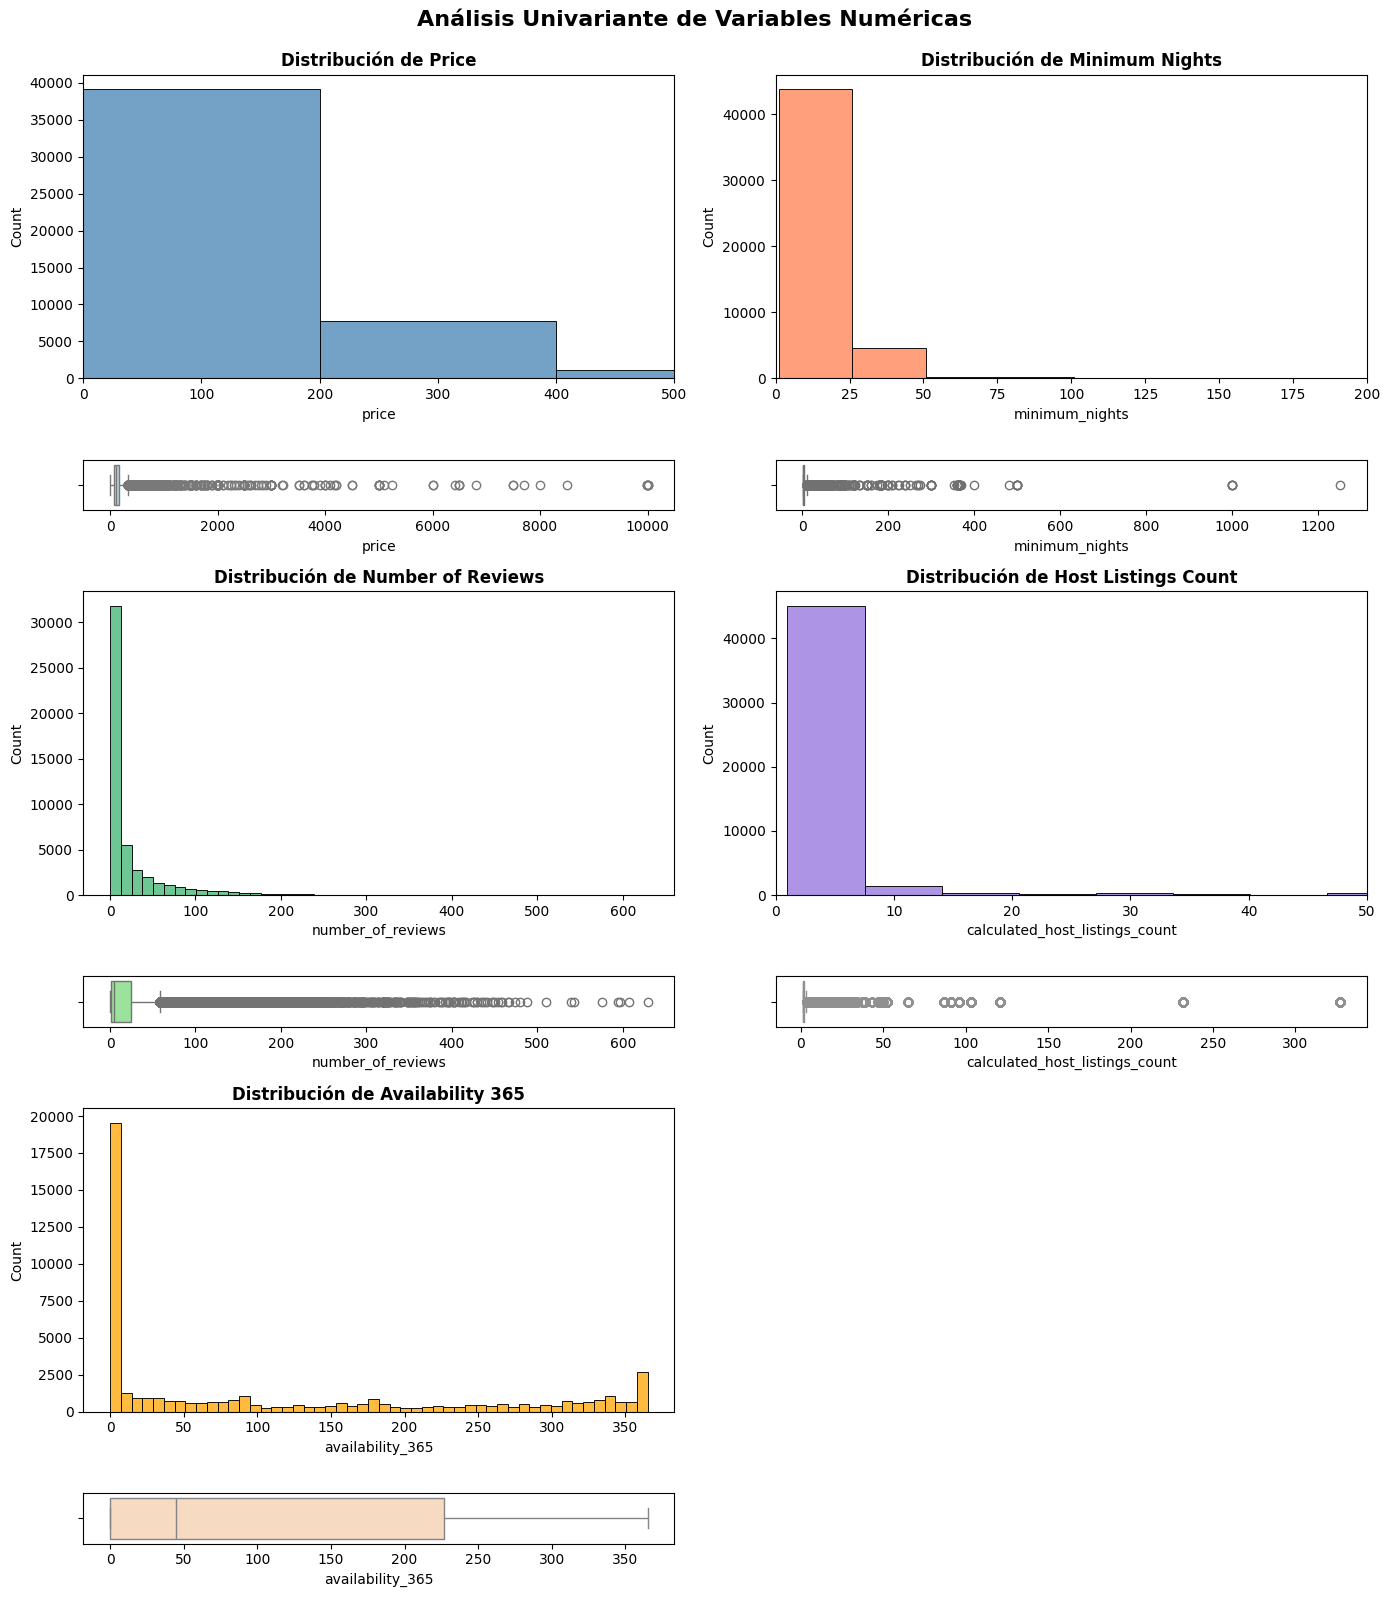

In [244]:
fig, axis = plt.subplots(6, 2, figsize=(14, 16), gridspec_kw={"height_ratios": [6, 1, 6, 1, 6, 1]})

# 1. PRICE (Fila 0-1, Columna 0)
sns.histplot(ax=axis[0, 0], data=df_clean, x="price", bins=50, color='steelblue')
axis[0, 0].set_title('Distribución de Price', fontsize=12, fontweight='bold')
axis[0, 0].set_xlim(0, 500)  # Limitar para ver mejor la distribución
sns.boxplot(ax=axis[1, 0], data=df_clean, x="price", color='lightblue')

# 2. MINIMUM NIGHTS (Fila 0-1, Columna 1)
sns.histplot(ax=axis[0, 1], data=df_clean, x="minimum_nights", bins=50, color='coral')
axis[0, 1].set_title('Distribución de Minimum Nights', fontsize=12, fontweight='bold')
axis[0, 1].set_xlim(0, 200)  # Limitar para ver mejor
sns.boxplot(ax=axis[1, 1], data=df_clean, x="minimum_nights", color='lightsalmon')

# 3. NUMBER OF REVIEWS (Fila 2-3, Columna 0)
sns.histplot(ax=axis[2, 0], data=df_clean, x="number_of_reviews", bins=50, color='mediumseagreen')
axis[2, 0].set_title('Distribución de Number of Reviews', fontsize=12, fontweight='bold')
sns.boxplot(ax=axis[3, 0], data=df_clean, x="number_of_reviews", color='lightgreen')

# 4. CALCULATED HOST LISTINGS COUNT (Fila 2-3, Columna 1)
sns.histplot(ax=axis[2, 1], data=df_clean, x="calculated_host_listings_count", bins=50, color='mediumpurple')
axis[2, 1].set_title('Distribución de Host Listings Count', fontsize=12, fontweight='bold')
axis[2, 1].set_xlim(0, 50)  # Limitar para ver mejor
sns.boxplot(ax=axis[3, 1], data=df_clean, x="calculated_host_listings_count", color='lavender')

# 5. AVAILABILITY 365 (Fila 4-5, Columna 0)
sns.histplot(ax=axis[4, 0], data=df_clean, x="availability_365", bins=50, color='orange')
axis[4, 0].set_title('Distribución de Availability 365', fontsize=12, fontweight='bold')
sns.boxplot(ax=axis[5, 0], data=df_clean, x="availability_365", color='peachpuff')

# Ocultar el subplot vacío (Fila 4-5, Columna 1)
axis[4, 1].set_visible(False)
axis[5, 1].set_visible(False)

# Ajustar diseño
plt.suptitle('Análisis Univariante de Variables Numéricas', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### ** 5 Analisis Multivariante



#### Analisis varaibles numericas
Se podria comparar el minimun_nights con price
Se podria comparar el room_type con price
Se podria comparar el neighbouthood_group con price
Se podria comparar el number of reviews con price

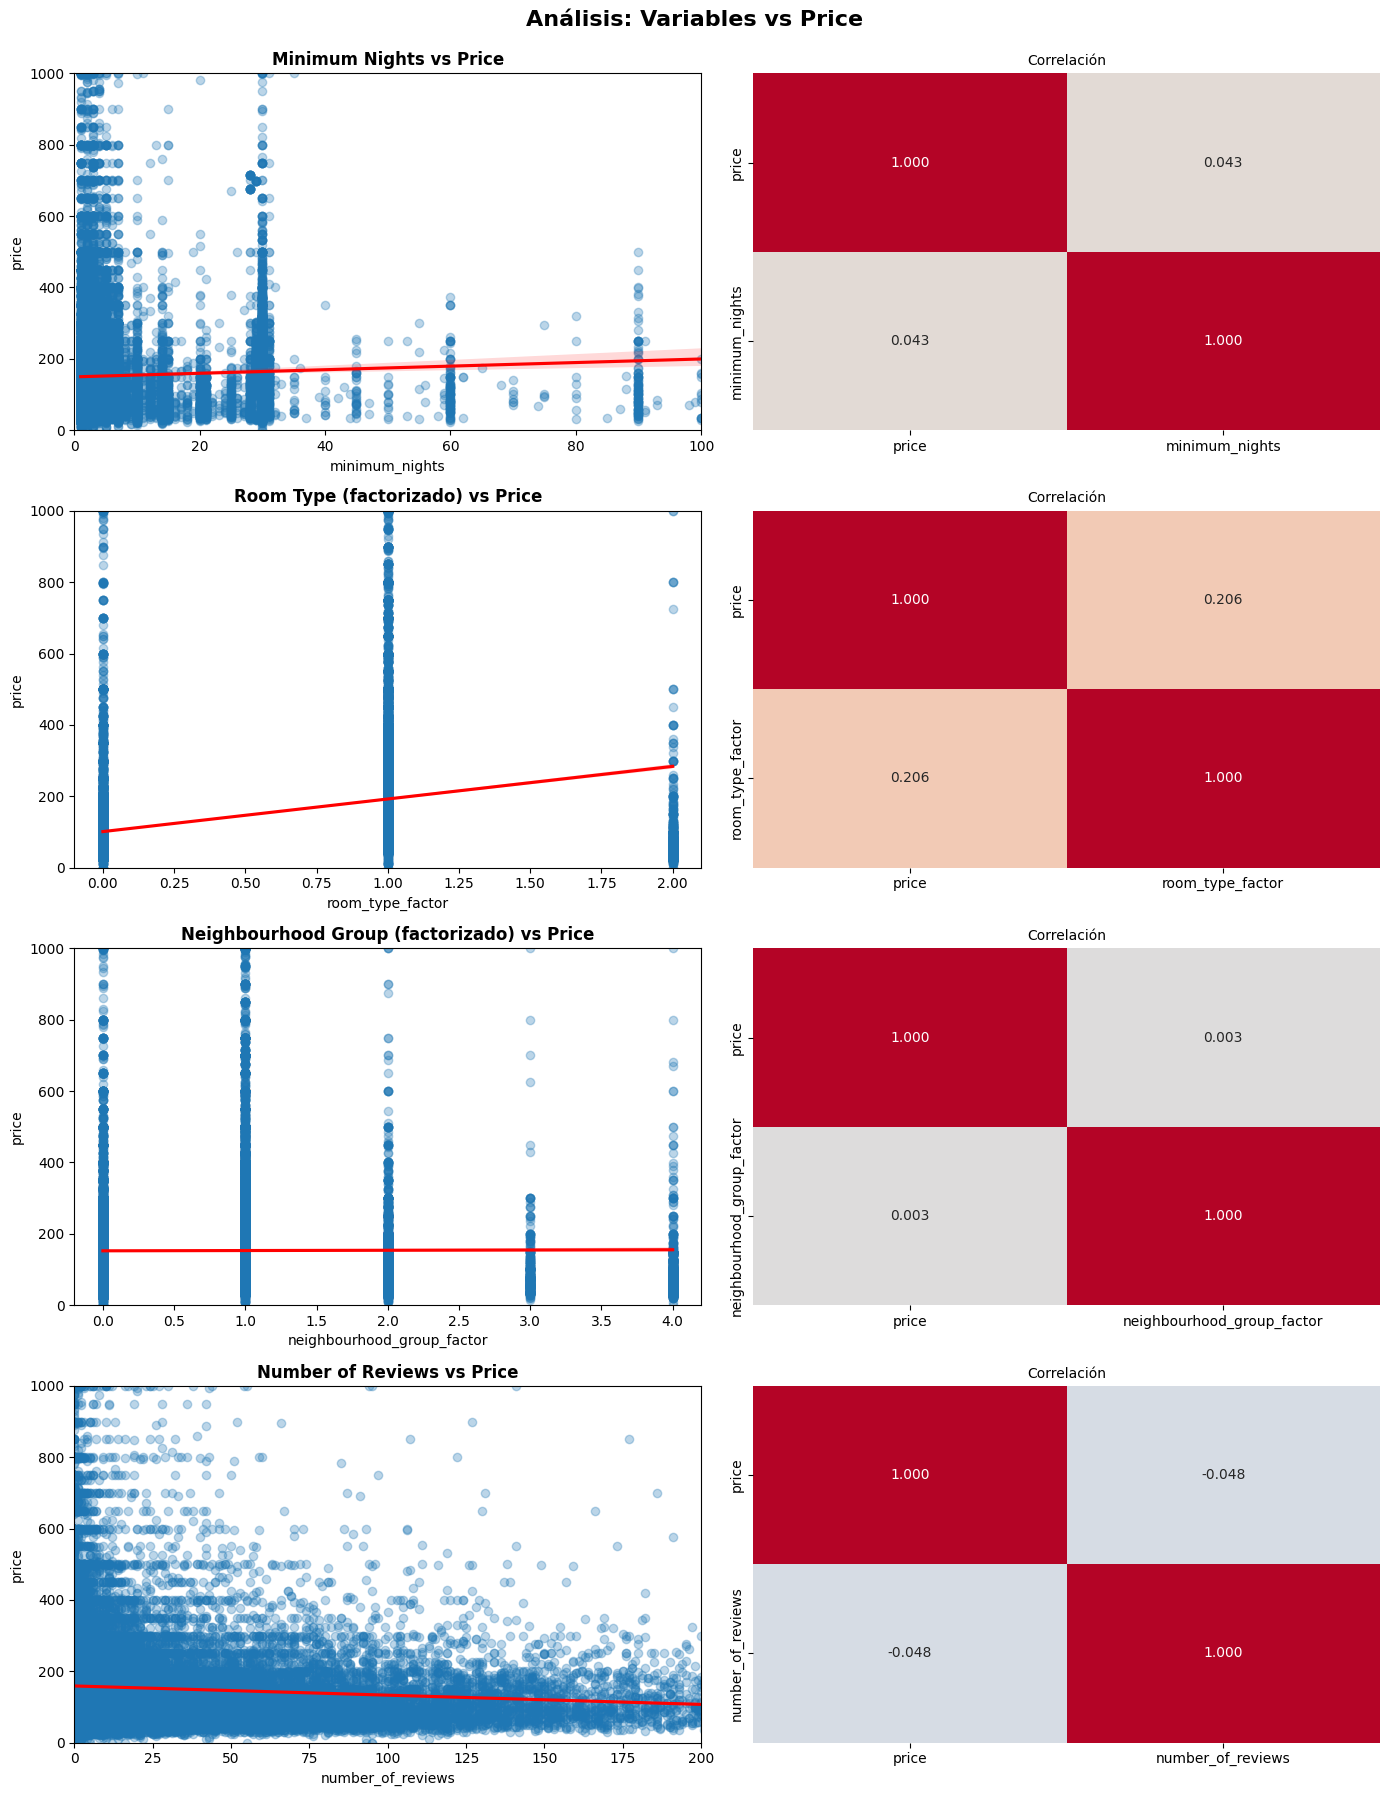

In [245]:
fig, axis = plt.subplots(4, 2, figsize=(14, 18))

# Comparo minimum_nights vs price
sns.regplot(ax=axis[0, 0], data=df_clean, x="minimum_nights", y="price", 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axis[0, 0].set_title('Minimum Nights vs Price', fontsize=12, fontweight='bold')
axis[0, 0].set_xlim(0, 100)  
axis[0, 0].set_ylim(0, 1000)
sns.heatmap(df_clean[["price", "minimum_nights"]].corr(), 
            annot=True, fmt=".3f", ax=axis[0, 1], cbar=False, cmap='coolwarm',
            vmin=-1, vmax=1)
axis[0, 1].set_title('Correlación', fontsize=10)

# Comparo room_type vs price
sns.regplot(ax=axis[1, 0], data=df_clean, x="room_type_factor", y="price",
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axis[1, 0].set_title('Room Type (factorizado) vs Price', fontsize=12, fontweight='bold')
axis[1, 0].set_ylim(0, 1000)
sns.heatmap(df_clean[["price", "room_type_factor"]].corr(), 
            annot=True, fmt=".3f", ax=axis[1, 1], cbar=False, cmap='coolwarm',
            vmin=-1, vmax=1)
axis[1, 1].set_title('Correlación', fontsize=10)

# Comparo neighbourhood_group vs price
sns.regplot(ax=axis[2, 0], data=df_clean, x="neighbourhood_group_factor", y="price",
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axis[2, 0].set_title('Neighbourhood Group (factorizado) vs Price', fontsize=12, fontweight='bold')
axis[2, 0].set_ylim(0, 1000)
sns.heatmap(df_clean[["price", "neighbourhood_group_factor"]].corr(), 
            annot=True, fmt=".3f", ax=axis[2, 1], cbar=False, cmap='coolwarm',
            vmin=-1, vmax=1)
axis[2, 1].set_title('Correlación', fontsize=10)

# Comparo number_of_reviews vs price
sns.regplot(ax=axis[3, 0], data=df_clean, x="number_of_reviews", y="price",
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axis[3, 0].set_title('Number of Reviews vs Price', fontsize=12, fontweight='bold')
axis[3, 0].set_xlim(0, 200)  # Limitar para ver mejor
axis[3, 0].set_ylim(0, 1000)
sns.heatmap(df_clean[["price", "number_of_reviews"]].corr(), 
            annot=True, fmt=".3f", ax=axis[3, 1], cbar=False, cmap='coolwarm',
            vmin=-1, vmax=1)
axis[3, 1].set_title('Correlación', fontsize=10)

# Ajustar diseño
plt.suptitle('Análisis: Variables vs Price', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

#### Analisis  variables categorica
Comparar room_type con precio
Comparar neighboourhood_group con precio


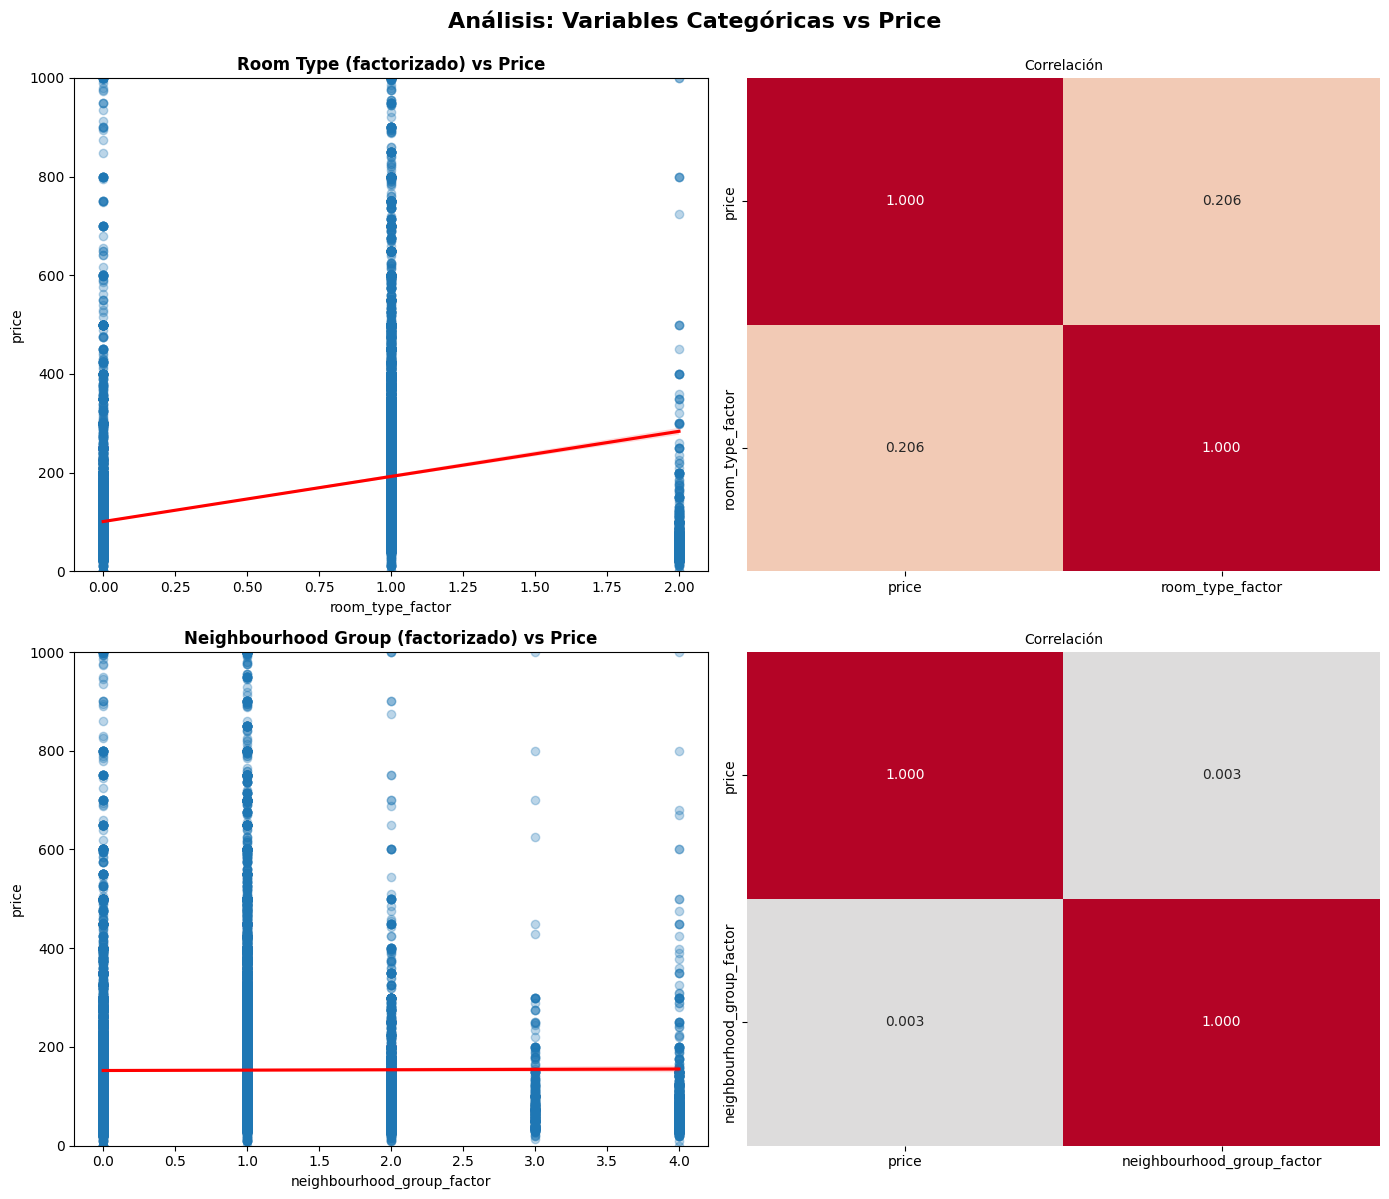

In [246]:
fig, axis = plt.subplots(2, 2, figsize=(14, 12))

# Row 0: room_type_factor vs price
sns.regplot(ax=axis[0, 0], data=df_clean, x="room_type_factor", y="price",
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axis[0, 0].set_title('Room Type (factorizado) vs Price', fontsize=12, fontweight='bold')
axis[0, 0].set_ylim(0, 1000)
sns.heatmap(df_clean[["price", "room_type_factor"]].corr(), 
            annot=True, fmt=".3f", ax=axis[0, 1], cbar=False, cmap='coolwarm',
            vmin=-1, vmax=1)
axis[0, 1].set_title('Correlación', fontsize=10)

# Row 1: neighbourhood_group_factor vs price
sns.regplot(ax=axis[1, 0], data=df_clean, x="neighbourhood_group_factor", y="price",
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axis[1, 0].set_title('Neighbourhood Group (factorizado) vs Price', fontsize=12, fontweight='bold')
axis[1, 0].set_ylim(0, 1000)
sns.heatmap(df_clean[["price", "neighbourhood_group_factor"]].corr(), 
            annot=True, fmt=".3f", ax=axis[1, 1], cbar=False, cmap='coolwarm',
            vmin=-1, vmax=1)
axis[1, 1].set_title('Correlación', fontsize=10)

# Ajustar diseño
plt.suptitle('Análisis: Variables Categóricas vs Price', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

Analizar todos los datos entre ellos

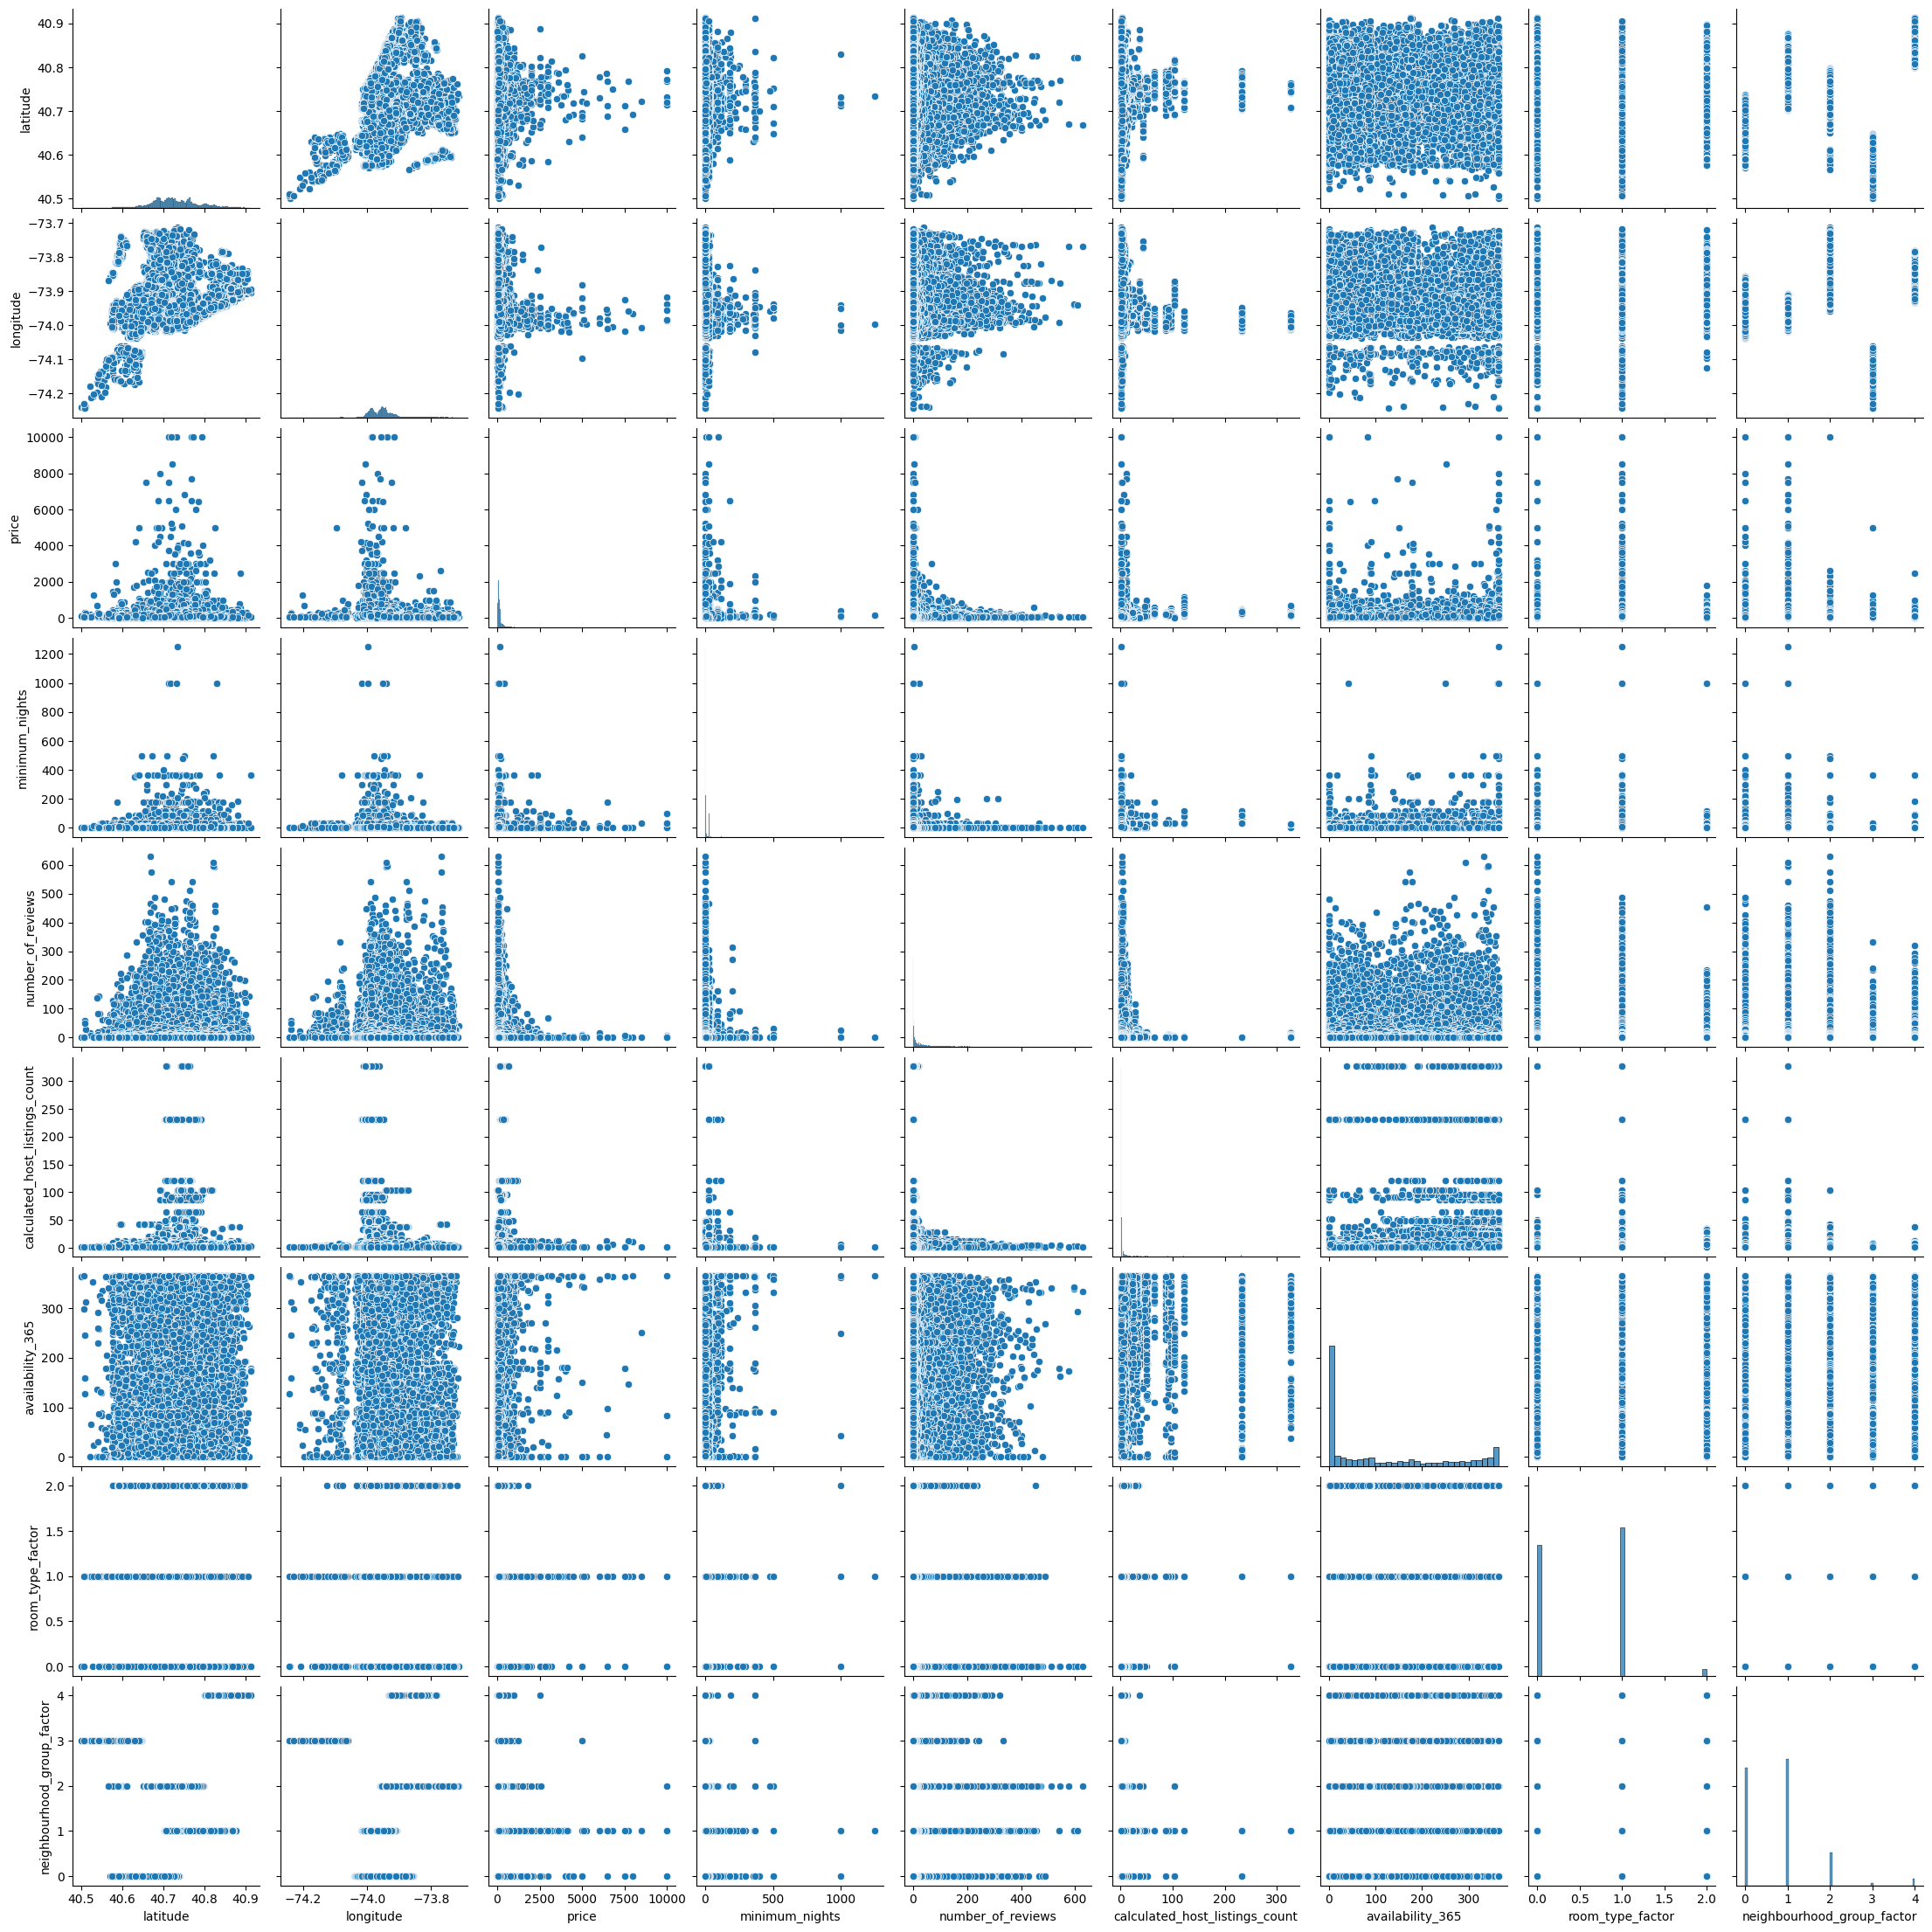

In [247]:
sns.pairplot(data = df_clean)

### **7. Análisis Numérico - Categórico**

En este apartado o sección vamos a combinar dos estrategias:

**1). Correlación únicamente para variables numéricas** (Person), para ver relaciones lineales entre continuas. Hay más tipos de correlación: Spearman, Kendall.

**Correlación de Pearson**

- Examina la **relación** entre dos variables. **Por ejempplo:** ¿Existe una relación entre la edad y el salario de una persona?

- Forma sencilla de medir que tán relacionadas están dos variables numéricas.

- **PALABRAS SIMPLES: MEDIDA DE DEPENDENCIA LINEAL ENTRE DOS VARIABLES**

- Matemáticamente la correlación es la covarianza pero dividida por las desviaciones estandas de las variables.

- Se representa con un número entre -1 y 1.
  - 1 > Relación perfecta positiva (si una sube, la otra también siempre)
  - 0 > No hay relación
  - -1 Relación perfecta negativa (si una sube la otra siempre baja)

- **NO** significa que una cause la otra. Solo indica que se mueven juntas.

**2). Relación numérico-categórico** mediante tasas/boxplots, sin usar Person con dummies.

In [248]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   calculated_host_listings_count  48895 non-null  int64  
 9   availability_365                48895 non-null  int64  
 10  room_type_factor                48895 non-null  int64  
 11  neighbourhood_group_factor      48895 non-null  int64  
dtypes: float64(2), int64(7), object(

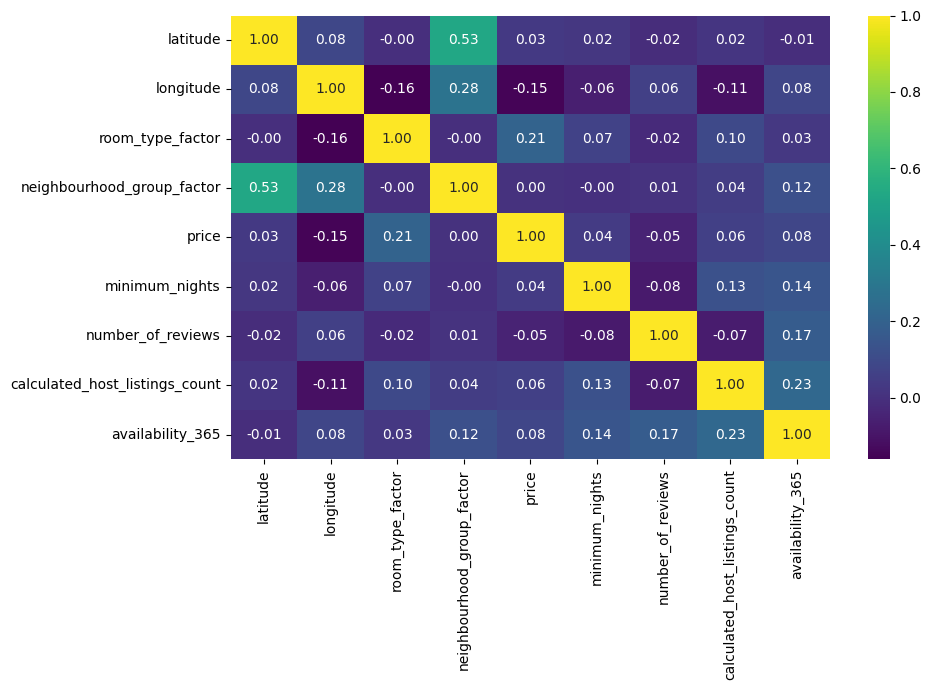

In [249]:


cols_num = ['latitude','longitude','room_type_factor','neighbourhood_group_factor',
            'price','minimum_nights', 'number_of_reviews',
            'calculated_host_listings_count', 'availability_365']


fig, ax= plt.subplots(figsize=(10, 7))
sns.heatmap(df_clean[cols_num].corr(method="pearson"),
            annot=True, fmt=".2f",cmap="viridis",ax=ax)
plt.tight_layout()
plt.show()

¿Que columnas descartar segun Correlacion?:
    - No hay ningun variable excesivamente relacionada con otra variable para eliminarla. 
    - Latitude, longitude y neightbouthood_factor estan altamente relacionadas, pero no lo suficiente para eliminarlas. Podria tener sentido, porque estas columnas identifican a localizacion en el mapa, pero por correlacion se deberian mantener.
    
    


### **8. Preparar los datos para Machine Learning**

En esta sección prepararemos el dataset para modelos de Machine Learning:

1. **Eliminar outliers** usando el método IQR (Interquartile Range)
2. **Normalizar/Escalar** variables numéricas al rango [0, 1] con MinMaxScaler

3. **Crear dataset final** `df_final` listo para modelado

- `lower_limit = Q1 - 1.5 × IQR`

**Criterio para outliers:**- `upper_limit = Q3 + 1.5 × IQR`

In [250]:
df_clean.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,room_type_factor,neighbourhood_group_factor
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,7.143982,112.781327,0.567113,0.786911
std,0.054530,0.046157,240.154170,20.510550,44.550582,32.952519,131.622289,0.541249,0.844386
min,40.499790,-74.244420,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,1.000000,45.000000,1.000000,1.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.000000,227.000000,1.000000,1.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,327.000000,365.000000,2.000000,4.000000


In [262]:
# Verificar tipos de datos

print("📊 Tipos de datos en df_clean:")
print(df_clean.dtypes)

📊 Tipos de datos en df_clean:
latitude                          float64
longitude                         float64
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
calculated_host_listings_count      int64
availability_365                    int64
room_type_factor                    int64
neighbourhood_group_factor          int64
dtype: object


#### **8.1 Visualización de Outliers**

Antes de eliminar outliers, visualicemos todas las variables numéricas:

<Axes: title={'center': 'Room Type (factorizado)'}, ylabel='room_type_factor'>

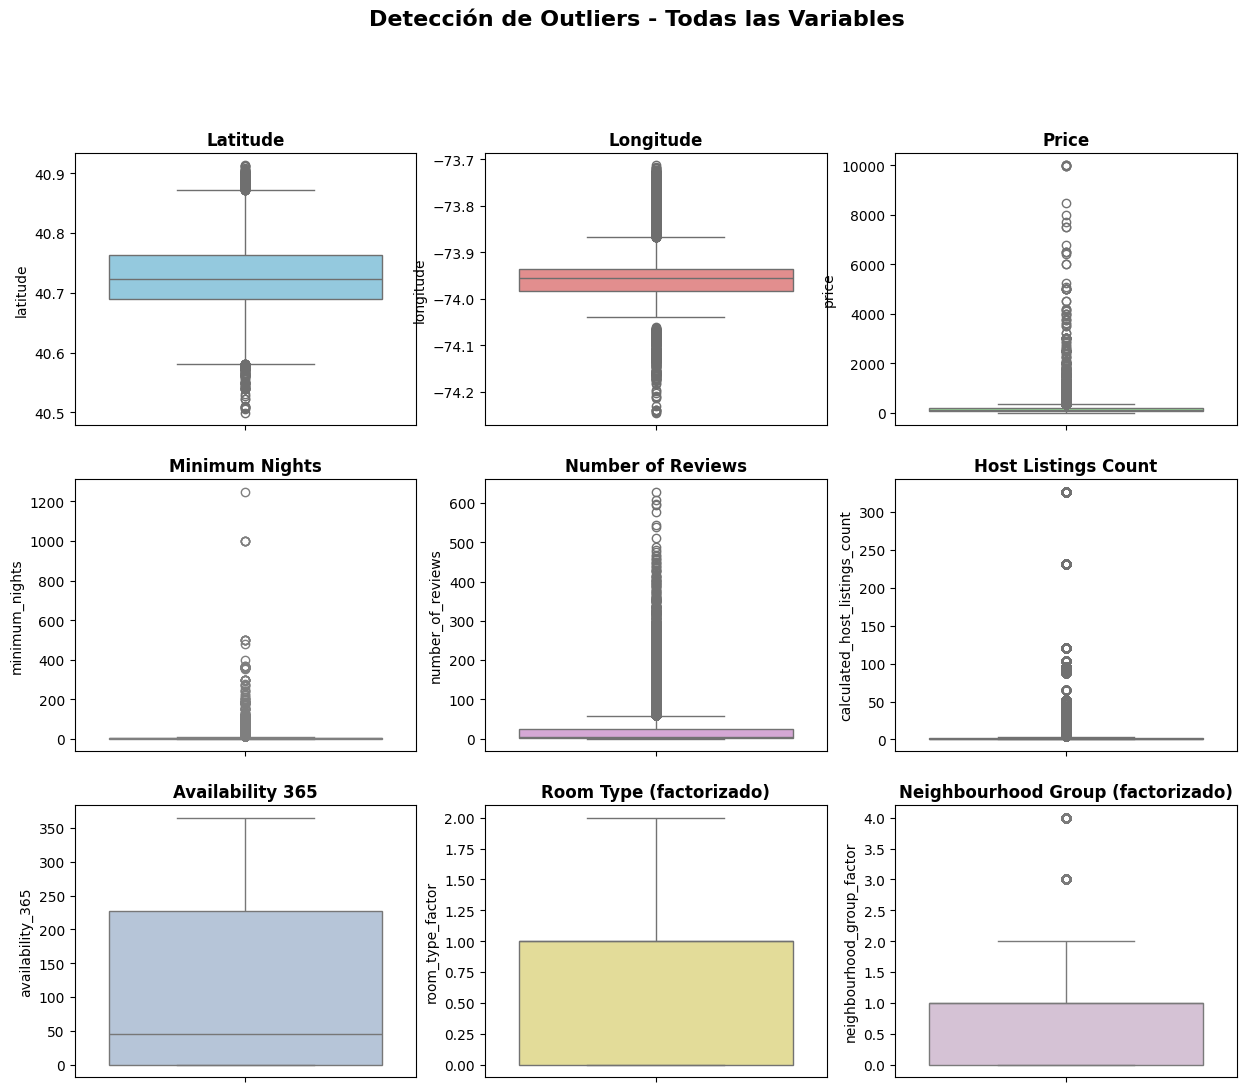

In [263]:
# Visualizar outliers en todas las variables numéricas
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Fila 0
sns.boxplot(ax=axes[0, 0], data=df_clean, y="latitude", color='skyblue')
axes[0, 0].set_title('Latitude', fontweight='bold')

sns.boxplot(ax=axes[0, 1], data=df_clean, y="longitude", color='lightcoral')
axes[0, 1].set_title('Longitude', fontweight='bold')

sns.boxplot(ax=axes[0, 2], data=df_clean, y="price", color='lightgreen')
axes[0, 2].set_title('Price', fontweight='bold')

# Fila 1
sns.boxplot(ax=axes[1, 0], data=df_clean, y="minimum_nights", color='wheat')
axes[1, 0].set_title('Minimum Nights', fontweight='bold')


sns.boxplot(ax=axes[1, 1], data=df_clean, y="number_of_reviews", color='plum')

axes[1, 1].set_title('Number of Reviews', fontweight='bold')

plt.suptitle('Detección de Outliers - Todas las Variables', fontsize=16, fontweight='bold', y=1.00)

sns.boxplot(ax=axes[1, 2], data=df_clean, y="calculated_host_listings_count", color='lightsalmon')

axes[1, 2].set_title('Host Listings Count', fontweight='bold')
axes[2, 2].set_title('Neighbourhood Group (factorizado)', fontweight='bold')

sns.boxplot(ax=axes[2, 2], data=df_clean, y="neighbourhood_group_factor", color='thistle')

# Fila 2

sns.boxplot(ax=axes[2, 0], data=df_clean, y="availability_365", color='lightsteelblue')
axes[2, 1].set_title('Room Type (factorizado)', fontweight='bold')

axes[2, 0].set_title('Availability 365', fontweight='bold')
sns.boxplot(ax=axes[2, 1], data=df_clean, y="room_type_factor", color='khaki')


#### **8.2 Eliminar Outliers**

Vamos a remover outliers de **price** usando el método IQR:

In [255]:
price_stats = df_clean["price"].describe()
price_stats

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [ ]:
# Calcular límites para outliers usando IQR
price_iqr = price_stats["75%"] - price_stats["25%"]
max_limit = price_stats["75%"] + 1.5 * price_iqr
min_limit = price_stats["25%"] - 1.5 * price_iqr

print(f"📊 Estadísticas de Price:")
print(f"   IQR: ${round(price_iqr, 2)}")
print(f"   Límite superior: ${round(max_limit, 2)}")

print(f"   Límite inferior: ${round(min_limit, 2)}")
print(f"\n📏 Registros antes de eliminar outliers: {len(df_clean):,}")

📊 Estadísticas de Price:
   IQR: $106.0
   Límite superior: $334.0
   Límite inferior: $-90.0

📏 Registros antes de eliminar outliers: 48,895


Elimino los outliers the **price** porque es mi columna a predecir.

In [ ]:
# Eliminar outliers de price usando los límites calculados
df_no_outliers = df_clean[
    (df_clean['price'] >= min_limit) & 
    (df_clean['price'] <= max_limit)
].copy()

outliers_removed = len(df_clean) - len(df_no_outliers)
percentage_removed = (outliers_removed / len(df_clean)) * 100

print(f"✂️  Outliers eliminados: {outliers_removed:,} ({percentage_removed:.2f}%)")
print(f"✅ Registros después de eliminar outliers: {len(df_no_outliers):,}")
print(f"\n📊 Nuevas estadísticas de Price:")
print(df_no_outliers['price'].describe())

✂️  Outliers eliminados: 2,972 (6.08%)
✅ Registros después de eliminar outliers: 45,923

📊 Nuevas estadísticas de Price:
count    45923.000000
mean       119.970320
std         68.150148
min          0.000000
25%         65.000000
50%        100.000000
75%        159.000000
max        334.000000
Name: price, dtype: float64


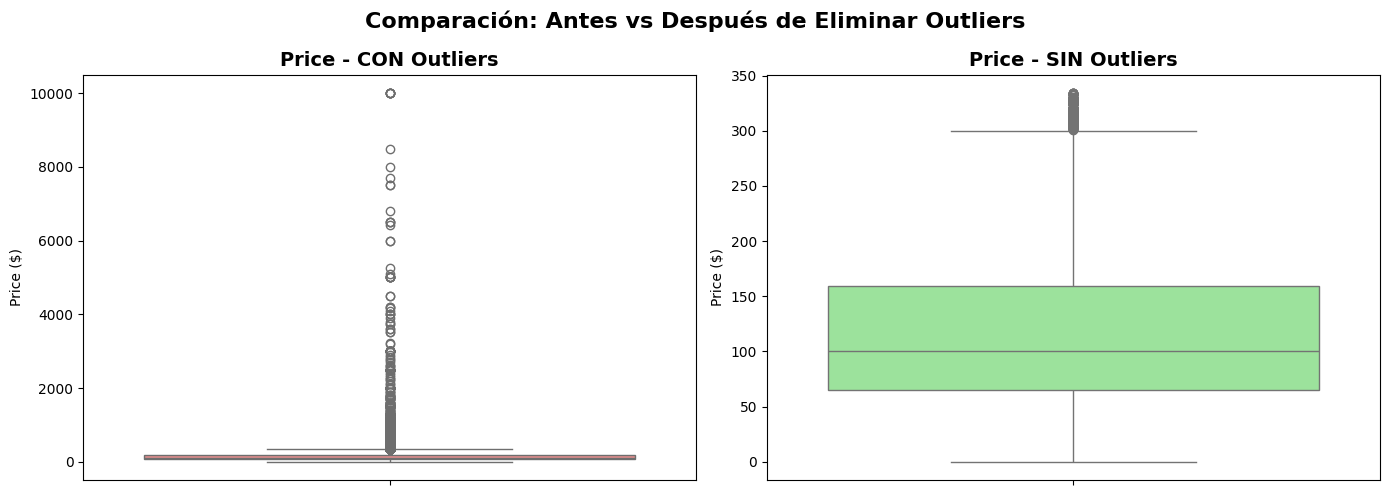

In [270]:
# Comparación visual: Antes vs Después de eliminar outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes de eliminar outliers
sns.boxplot(ax=axes[0], data=df_clean, y='price', color='lightcoral')
axes[0].set_title('Price - CON Outliers', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)')

# Después de eliminar outliers
sns.boxplot(ax=axes[1], data=df_no_outliers, y='price', color='lightgreen')
axes[1].set_title('Price - SIN Outliers', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price ($)')

plt.suptitle('Comparación: Antes vs Después de Eliminar Outliers', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### **8.3 Normalización con MinMaxScaler**

Escalaremos las variables numéricas al rango [0, 1] para que todas tengan la misma escala:

In [285]:
from sklearn.preprocessing import MinMaxScaler

# Seleccionar variables numéricas para escalar (excepto las ya factorizadas)
num_variables_to_scale = ["latitude", "longitude", "price", "minimum_nights", 
                          "number_of_reviews", "calculated_host_listings_count", 
                          "availability_365"]

print(f"📊 Variables a escalar: {num_variables_to_scale}\n")

# Crear el escalador y ajustar a los datos
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df_no_outliers[num_variables_to_scale])

# Crear DataFrame con las columnas escaladas
df_scaled = pd.DataFrame(
    scaled_features, 
    index=df_no_outliers.index, 
    columns=[f"{col}_scaled" for col in num_variables_to_scale]
)

# Mostrar comparación de valores originales vs escalados
print("🔄 Comparación: Originales vs Escalados (primeras 5 filas)")
print("\nOriginales:")
print(df_no_outliers[num_variables_to_scale].head())
print("\nEscalados (rango 0-1):")
print(df_scaled.head())

📊 Variables a escalar: ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365']

🔄 Comparación: Originales vs Escalados (primeras 5 filas)

Originales:
   latitude  longitude  price  minimum_nights  number_of_reviews  \
0  40.64749  -73.97237    149               1                  9   
1  40.75362  -73.98377    225               1                 45   
2  40.80902  -73.94190    150               3                  0   
3  40.68514  -73.95976     89               1                270   
4  40.79851  -73.94399     80              10                  9   

   calculated_host_listings_count  availability_365  
0                               6               365  
1                               2               355  
2                               1               365  
3                               1               194  
4                               1                 0  

Escalados (rango 0-1):
   latitude_scaled  

#### **8.4 Crear Dataset Final para Machine Learning**

Combinaremos las variables escaladas con las variables factorizadas:

In [286]:
# Crear dataset final combinando variables escaladas y factorizadas
df_final = df_scaled.copy()

# Agregar variables categóricas factorizadas (ya están en el rango apropiado)
df_final["room_type_factor"] = df_no_outliers["room_type_factor"]
df_final["neighbourhood_group_factor"] = df_no_outliers["neighbourhood_group_factor"]

print("="*70)
print("📦 DATASET FINAL PARA MACHINE LEARNING")
print("="*70)
print(f"\n✅ Shape: {df_final.shape[0]:,} filas × {df_final.shape[1]} columnas")
print(f"\n📋 Columnas incluidas:")
for i, col in enumerate(df_final.columns, 1):
    print(f"   {i}. {col}")

print(f"\n📊 Información del dataset:")
print(df_final.info())

print(f"\n🔢 Estadísticas descriptivas:")
print(df_final.describe())

📦 DATASET FINAL PARA MACHINE LEARNING

✅ Shape: 45,923 filas × 9 columnas

📋 Columnas incluidas:
   1. latitude_scaled
   2. longitude_scaled
   3. price_scaled
   4. minimum_nights_scaled
   5. number_of_reviews_scaled
   6. calculated_host_listings_count_scaled
   7. availability_365_scaled
   8. room_type_factor
   9. neighbourhood_group_factor

📊 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 45923 entries, 0 to 48894
Data columns (total 9 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   latitude_scaled                        45923 non-null  float64
 1   longitude_scaled                       45923 non-null  float64
 2   price_scaled                           45923 non-null  float64
 3   minimum_nights_scaled                  45923 non-null  float64
 4   number_of_reviews_scaled               45923 non-null  float64
 5   calculated_host_listings_count_scaled 

In [287]:
# Visualizar las primeras filas del dataset final
df_final.head(10)

,latitude_scaled,longitude_scaled,price_scaled,minimum_nights_scaled,number_of_reviews_scaled,calculated_host_listings_count_scaled,availability_365_scaled,room_type_factor,neighbourhood_group_factor
0,0.357393,0.511921,0.446108,0.000000,0.014308,0.015337,1.000000,0,0
1,0.614199,0.490469,0.673653,0.000000,0.071542,0.003067,0.972603,1,1
2,0.748252,0.569257,0.449102,0.001601,0.000000,0.000000,1.000000,0,1
3,0.448496,0.535649,0.266467,0.000000,0.429253,0.000000,0.531507,1,0
4,0.722820,0.565324,0.239521,0.007206,0.014308,0.000000,0.000000,1,1
5,0.599802,0.506972,0.598802,0.001601,0.117647,0.000000,0.353425,1,1
6,0.452706,0.542800,0.179641,0.035228,0.077901,0.000000,0.000000,0,0
7,0.641469,0.488286,0.236527,0.000801,0.683625,0.000000,0.602740,0,1
8,0.730733,0.521593,0.236527,0.000801,0.187599,0.000000,0.000000,0,1
9,0.516974,0.478050,0.449102,0.000000,0.254372,0.009202,0.515068,1,1


#### **8.5 Resumen de Preparación**

**✅ Tareas completadas:**

1. **Outliers eliminados:** {outliers_removed:,} registros ({percentage_removed:.1f}%) usando método IQR en variable `price`
2. **Normalización:** Todas las variables numéricas escaladas al rango [0, 1] con MinMaxScaler
3. **Variables incluidas:** 
   - 7 variables numéricas escaladas (latitude, longitude, price, minimum_nights, number_of_reviews, calculated_host_listings_count, availability_365)
   - 2 variables categóricas factorizadas (room_type_factor, neighbourhood_group_factor)

4. **Dataset final:** `df_final` con {df_final.shape[0]:,} registros y {df_final.shape[1]} variables

**📈 Próximos pasos:**
- Dividir en conjuntos de entrenamiento y prueba (train/test split)
- Seleccionar algoritmo de Machine Learning
- Entrenar y evaluar modelos

### **9. Crear training and test dataset

In [288]:
from sklearn.feature_selection import f_regression, SelectKBest
from sklearn.model_selection import train_test_split

# Separar features (X) y target (y)
X = df_final.drop("price_scaled", axis = 1)
y = df_final["price_scaled"]

# Dividir en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Selección de características usando f_regression (apropiado para regresión)
# f_regression calcula la correlación entre cada variable y el target
selection_model = SelectKBest(f_regression, k = 4)
selection_model.fit(X_train, y_train)
ix = selection_model.get_support()

# Crear DataFrames con las 4 mejores características seleccionadas
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

print(f"Features originales: {X_train.shape[1]}")
print(f"Features seleccionadas: {X_train_sel.shape[1]}")
print(f"\n📋 Características seleccionadas:")
for i, col in enumerate(X_train_sel.columns, 1):
    print(f"   {i}. {col}")

X_train_sel.head()

Features originales: 8
Features seleccionadas: 4

📋 Características seleccionadas:
   1. latitude_scaled
   2. longitude_scaled
   3. calculated_host_listings_count_scaled
   4. room_type_factor


,latitude_scaled,longitude_scaled,calculated_host_listings_count_scaled,room_type_factor
0,0.614586,0.674068,0.003067,0.0
1,0.433518,0.627834,0.009202,0.0
2,0.520241,0.460475,0.000000,0.0
3,0.538583,0.494778,0.003067,0.0
4,0.495439,0.901003,0.000000,1.0


In [289]:
X_train_sel["price"] = list(y_train)
X_test_sel["price"] = list(y_test)
X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index = False)

---

# Otras maneras de hacer EDA


## Pandas Profiling

In [290]:
# Install required dependencies - Run this cell first, then RESTART KERNEL
import sys
!{sys.executable} -m pip install --upgrade pip setuptools wheel
!{sys.executable} -m pip install ydata-profiling

print("\n" + "="*70)
print("⚠️  IMPORTANT: After installation completes, RESTART THE KERNEL")
print("   Go to: Kernel > Restart Kernel")
print("   Then run the next cell to generate the report")
print("="*70)


⚠️  IMPORTANT: After installation completes, RESTART THE KERNEL
   Go to: Kernel > Restart Kernel
   Then run the next cell to generate the report


In [291]:
# ============================================================
# COMPREHENSIVE EDA REPORT - Airbnb NYC Dataset
# ============================================================

print("="*70)
print("📊 AIRBNB NYC 2019 - COMPREHENSIVE EDA REPORT")
print("="*70)

# 1. BASIC INFORMATION
print("\n1️⃣ DATASET OVERVIEW")
print("-"*70)
print(f"   • Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   • Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"   • Duplicate Rows: {df.duplicated().sum()}")

# 2. COLUMN INFORMATION
print("\n2️⃣ COLUMN TYPES")
print("-"*70)
for dtype, count in df.dtypes.value_counts().items():
    print(f"   • {dtype}: {count} columns")

print("\n   Numeric columns:", list(df.select_dtypes(include=[np.number]).columns))
print("   Categorical columns:", list(df.select_dtypes(include=['object']).columns))

# 3. MISSING VALUES
print("\n3️⃣ MISSING VALUES ANALYSIS")
print("-"*70)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)

if len(missing_df) > 0:
    for _, row in missing_df.iterrows():
        print(f"   • {row['Column']:25} {row['Missing Count']:>6} ({row['Percentage']:>5.2f}%)")
else:
    print("   ✅ No missing values detected!")

# 4. DESCRIPTIVE STATISTICS
print("\n4️⃣ NUMERICAL VARIABLES STATISTICS")
print("-"*70)
display(df.describe().T.style.background_gradient(cmap='YlOrRd'))

# 5. CATEGORICAL VARIABLES
print("\n5️⃣ CATEGORICAL VARIABLES DISTRIBUTION")
print("-"*70)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    unique_count = df[col].nunique()
    print(f"\n   📌 {col}: {unique_count} unique values")
    if unique_count <= 10:
        value_counts = df[col].value_counts().head(10)
        for val, count in value_counts.items():
            pct = (count / len(df)) * 100
            print(f"      • {str(val):30} {count:>6} ({pct:>5.2f}%)")
    else:
        print(f"      Top 5 most frequent:")
        value_counts = df[col].value_counts().head(5)
        for val, count in value_counts.items():
            pct = (count / len(df)) * 100
            print(f"      • {str(val):30} {count:>6} ({pct:>5.2f}%)")

# 6. OUTLIERS DETECTION (IQR Method)
print("\n6️⃣ OUTLIERS DETECTION (IQR Method)")
print("-"*70)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    outlier_pct = (len(outliers) / len(df)) * 100
    if outlier_pct > 0:
        print(f"   • {col:35} {len(outliers):>6} outliers ({outlier_pct:>5.2f}%)")

# 7. CORRELATION HIGHLIGHTS
print("\n7️⃣ TOP CORRELATIONS (|r| > 0.5)")
print("-"*70)
if len(df.select_dtypes(include=[np.number]).columns) > 1:
    corr_matrix = df.select_dtypes(include=[np.number]).corr()
    
    # Get upper triangle of correlation matrix
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5:
                corr_pairs.append({
                    'var1': corr_matrix.columns[i],
                    'var2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    
    if corr_pairs:
        corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x['correlation']), reverse=True)
        for pair in corr_pairs_sorted:
            print(f"   • {pair['var1']:30} <-> {pair['var2']:30} | r = {pair['correlation']:>6.3f}")
    else:
        print("   ℹ️  No strong correlations (|r| > 0.5) found")

# 8. SUMMARY RECOMMENDATIONS
print("\n8️⃣ KEY RECOMMENDATIONS")
print("-"*70)
print("   ✓ Missing values identified - consider imputation strategies")
print("   ✓ Outliers detected - evaluate if removal or transformation needed")
print("   ✓ Categorical variables - consider encoding for ML models")
print("   ✓ Check correlation matrix for multicollinearity issues")

print("\n" + "="*70)
print("✅ EDA REPORT COMPLETE")
print("="*70)

📊 AIRBNB NYC 2019 - COMPREHENSIVE EDA REPORT

1️⃣ DATASET OVERVIEW
----------------------------------------------------------------------
   • Shape: 48,895 rows × 16 columns
   • Memory Usage: 21.28 MB
   • Duplicate Rows: 0

2️⃣ COLUMN TYPES
----------------------------------------------------------------------
   • int64: 7 columns
   • object: 6 columns
   • float64: 3 columns

   Numeric columns: ['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
   Categorical columns: ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']

3️⃣ MISSING VALUES ANALYSIS
----------------------------------------------------------------------
   • last_review                10052 (20.56%)
   • reviews_per_month          10052 (20.56%)
   • host_name                     21 ( 0.04%)
   • name                          16 ( 0.03%)

4️⃣ NUMERICAL VARIABLES ST

,count,mean,std,min,25%,50%,75%,max
id,48895.000000,19017143.236180,10983108.385610,2539.000000,9471945.000000,19677284.000000,29152178.500000,36487245.000000
host_id,48895.000000,67620010.646610,78610967.032667,2438.000000,7822033.000000,30793816.000000,107434423.000000,274321313.000000
latitude,48895.000000,40.728949,0.054530,40.499790,40.690100,40.723070,40.763115,40.913060
longitude,48895.000000,-73.952170,0.046157,-74.244420,-73.983070,-73.955680,-73.936275,-73.712990
price,48895.000000,152.720687,240.154170,0.000000,69.000000,106.000000,175.000000,10000.000000
minimum_nights,48895.000000,7.029962,20.510550,1.000000,1.000000,3.000000,5.000000,1250.000000
number_of_reviews,48895.000000,23.274466,44.550582,0.000000,1.000000,5.000000,24.000000,629.000000
reviews_per_month,38843.000000,1.373221,1.680442,0.010000,0.190000,0.720000,2.020000,58.500000
calculated_host_listings_count,48895.000000,7.143982,32.952519,1.000000,1.000000,1.000000,2.000000,327.000000
availability_365,48895.000000,112.781327,131.622289,0.000000,0.000000,45.000000,227.000000,365.000000



5️⃣ CATEGORICAL VARIABLES DISTRIBUTION
----------------------------------------------------------------------

   📌 name: 47905 unique values
      Top 5 most frequent:
      • Hillside Hotel                     18 ( 0.04%)
      • Home away from home                17 ( 0.03%)
      • New york Multi-unit building       16 ( 0.03%)
      • Brooklyn Apartment                 12 ( 0.02%)
      • Loft Suite @ The Box House Hotel     11 ( 0.02%)

   📌 host_name: 11452 unique values
      Top 5 most frequent:
      • Michael                           417 ( 0.85%)
      • David                             403 ( 0.82%)
      • Sonder (NYC)                      327 ( 0.67%)
      • John                              294 ( 0.60%)
      • Alex                              279 ( 0.57%)

   📌 neighbourhood_group: 5 unique values
      • Manhattan                       21661 (44.30%)
      • Brooklyn                        20104 (41.12%)
      • Queens                           5666 (11.59%)
      